# Exercise 1 : Lemmatization



## Dataset
To train or build your lemmatizer you have three files in *tabular separated values* format :
* [training-set.tsv](https://thomas-gerald.fr/TMC/resources/data/training-set.tsv) that you can use to train/build your dictionnary/model 
* [testing-set.tsv](https://thomas-gerald.fr/TMC/resources/data/testing-set.tsv) used to evaluate the different approaches
* [testing-gallica.tsv](https://thomas-gerald.fr/TMC/resources/data/testing-gallica.tsv) used as gold standard to evaluate performances [github (in french)](https://github.com/Gallicorpora/Lemmatisation)

In our case we have two possibilities for a lemma:
* (a) A sequence of characters, meaning that "to rule" an "a rule" are the same lemma
* (b) A sequence of characters, meaning that "to rule" represent the verb, a tuple ("rule", "V") while "a rule" is represented by the tuple ("rule", "N") 
In the (a) case the size of the vocabulary (output) will be 

## Notebook overview

**What is lemmatization?**

Lemmatization reduces a token-word to its lemma form. For example, *mangeaient* is mapped to *manger*, and *belles* to *beau*. It is a common preprocessing step in NLP, used to group together the different forms of the same word.

**Goal of this notebook**

The aim of this notebook is to build and compare several French lemmatization approaches from scratch, ranging from a simple dictionary-based baseline to a neural sequence model. All models are evaluated using the same protocol, while also studying how their performance changes when **part-of-speech (POS) information** is provided as an additional input. The best system is finally compared with the spaCy lemmatizer.

**Key idea: predicting edit rules instead of lemmas**

Instead of predicting the lemma directly, each `(token, lemma)` pair is represented as a simple **edit rule** describing how to transform the word into its lemma. A rule specifies how many characters should be removed from the end of the token and which suffix, if any, should be added (e.g. `négociée → négocier` is encoded as `-2|+er`).

This turns lemmatization into a classification problem with a relatively small number of possible transformations, rather than requiring the model to choose among thousands of possible lemma strings. It also allows the models to apply learned transformations to words that were not seen during training.

**Workflow**

| Step | Section | What happens |
|---|---|---|
| Reference | 1 | spaCy as an off-the-shelf point of comparison |
| Data | 2 | Load the three TSV corpora, harmonise the Gallica POS tags and describe the data |
| Preprocessing | 3 | Lowercase, deduplicate, encode lemmas as edit rules, filter rare rules, measure train/test overlap |
| Baseline | 4 | Dictionary lemmatizers (lookup), with and without POS |
| Classical ML | 5 | Character n-grams + Logistic Regression / SVC / KNN / Decision Tree, with and without POS, then the best model tested on unseen words |
| Neural model | 6–7 | Character-level LSTM predicting the edit rule, without (6) and with (7) POS |
| Combination | 8 | Hybrid pipeline: dictionary first, LSTM as fallback for unknown words (three variants) |
| Final comparison | 9 | Best hybrid model vs spaCy, on the test set and on the out-of-domain Gallica corpus |
| Conclusions | 10 | Global results table, main findings and limitations |

Each section ends with a short **Summary** cell with its key numbers and takeaways.

**Evaluation metrics**

Two different evaluation measures are used throughout the notebook, depending on what is being evaluated.

- **Lemma accuracy** measures whether the final predicted lemma exactly matches the correct lemma. This metric is used for the dictionary-based approaches (Section 4), the hybrid pipelines (Section 8) and the comparison with spaCy (Section 9). It is computed over the **entire test set**, i.e. over every token occurrence, so frequent words weigh more.

- **Rule balanced accuracy** measures whether the model predicts the correct edit rule, averaged per rule class (mean of the per-class recall), so that the very frequent identity rule as `0|+` does not dominate the score. This metric is used for the machine learning (Section 5) and LSTM models (Sections 6–7). It is reported either during cross-validation on the training data or on a specific **generalization subset** of the test set.

The generalization subset contains words that were **not seen during training**, but whose correct edit rule was present in the training data. This allows us to evaluate whether the models have learned transformations that can be applied to new words, rather than simply memorizing known tokens.

All four learned configurations — SVC and LSTM, with and without POS information — are evaluated on this same subset, making their results directly comparable.

> **Headline result.** The best system was a frequency dictionary for known words with a POS-aware LSTM as fallback (Section 8.5). This model reaches a lemma accuracy of **0.9623** on the test set, compared with **0.9156** for the dictionary alone and **0.6641** for spaCy under the same evaluation setting (Section 9). On the Gallica dataset, the same hybrid approach achieved the best performance, with a lemma accuracy of **52.76%**, compared with **46.80%** for the frequency dictionary alone, **42.41%** for spaCy (English) and **%** for spaCy (French).

## 1. Reference point: the spaCy lemmatizer 


In [1]:
'''! python -m spacy download en_core_web_sm
! python -m spacy download fr_core_news_sm
! pip install nltk pandas scikit-learn numpy torch'''

'! python -m spacy download en_core_web_sm\n! python -m spacy download fr_core_news_sm\n! pip install nltk pandas scikit-learn numpy torch'

In [2]:
import spacy
nlp = spacy.load("en_core_web_sm")
text_a = "He is thirty years old"
text_b = "We still are champions"
print(f'Lemmatization A : {[(w.lemma_, w.pos_) for w in nlp(text_a)]}')
print(f'Lemmatization B : {[(w.lemma_, w.pos_) for w in nlp(text_b)]}')

Lemmatization A : [('he', 'PRON'), ('be', 'AUX'), ('thirty', 'NUM'), ('year', 'NOUN'), ('old', 'ADJ')]
Lemmatization B : [('we', 'PRON'), ('still', 'ADV'), ('be', 'AUX'), ('champion', 'NOUN')]


### Summary of Section 1
- This example uses the English pipeline (`en_core_web_sm`) on English sentences for illustration only. For this exercise, the relevant reference is the French pipeline (`fr_core_news_sm`). spaCy is evaluated quantitatively in Section 9.

---

## 2. The data


### 2.1 Loading the corpora

The dataset is provided in three tab-separated files. Each row is one **token occurrence** from running text, with its `token`, its gold `lemma` and its gold `POS` tag. Because rows follow the original text, frequent words (articles, punctuation, auxiliaries…) appear many times.

- **`training-set.tsv`** contains the data used to build the dictionary-based lemmatizer and train the different models.
- **`testing-set.tsv`** is kept separate from the training data and is used to evaluate the different approaches (Sections 4 to 9).
- **`testing-gallica.tsv`** contains an additional gold standard from the [Gallicorpora](https://github.com/Gallicorpora/Lemmatisation). It is used only in Section 9, as an **out-of-domain** test.

The Gallica file needs some harmonisation, done in the next cell: its columns are renamed (`form` → `token`, `POS` → `pos`), the `morph` column is dropped, and its fine-grained POS tags (e.g. `VERcjg`, `DETdef`, `PRE.DETdef`) are mapped onto the coarse tagset of the training data (`V`, `D`, `P+D`, …) with `transform_pos_gallica`. Tokens tagged `OUT` have no equivalent and are left without a POS tag.

In [ ]:
import pandas as pd
import numpy as np

train_file = "data/raw/training-set.tsv"
test_file = "data/raw/testing-set.tsv"
output_file = "data/raw/testing-gallica.tsv"

data_train=pd.read_csv(train_file, sep='\t', names=["token", "lemma", "pos"])
set_train_pos = set(data_train['pos'].unique())

data_test=pd.read_csv(test_file, sep='\t', names=["token", "lemma", "pos"])
set_test_pos = set(data_test['pos'].unique())

data_gallica=pd.read_csv(output_file, sep='\t',header=0)
# gallica set needs more preprocessing, so we will not use it for now


print('TRAIN SET SAMPLE')
display(data_train.head())
print(f'Information about the training set : {data_train.shape}')
print(f'The number of unique tokens is :  {data_train["token"].nunique()}')
print(f'The number of unique lemmas is :  {data_train["lemma"].nunique()}')
print(f'The number of unique pos is :  {data_train["pos"].nunique()} and the unique pos are : {data_train["pos"].unique()}')
print('------------------------------------------------------------------------------')


print('TEST SET SAMPLE')
display(data_test.head())
print(f'Information about the test set : {data_test.shape}')
print(f'The number of unique tokens is :  {data_test["token"].nunique()}')
print(f'The number of unique lemmas is :  {data_test["lemma"].nunique()}')
print(f'The number of unique pos is :  {data_test["pos"].nunique()} and the unique pos are : {data_test["pos"].unique()}')
print('------------------------------------------------------------------------------')


print('GALLICA SET SAMPLE')
data_gallica.rename(columns={"form": "token", "lemma": "lemma", "POS": "pos",'morph': 'morph'}, inplace=True)

def transform_pos_gallica(pos):
    pos_mapping = {
        "PROper": "PRO",
        "VERcjg": "V",
        "DETdef": "D",
        "ADVgen": "ADV",
        "ADJqua": "A",
        "CONcoo": "C",
        "NOMcom": "N",
        "PRE": "P",
        "DETpos": "D",
        "NOMpro": "N",
        "VERppe": "V",
        "PONfrt": "PONCT",
        "OUT": np.nan,
        "PONfbl": "PONCT",
        "DETndf": "D",
        "DETcar": "D",
        "DETdem": "D",
        "CONsub": "C",
        "VERinf": "V",
        "DETind": "D",
        "PROdem": "PRO",
        "PROrel": "PRO",
        "PRE.DETdef": "P+D",
        "PROind": "PRO",
        "ADVneg": "ADV",
        "PROadv": "CL",
        "PROpos": "PRO",
        "VERppa": "V",
        "PRE.PROrel": "P+PRO",
        "ADJind": "A",
        "ADJcar": "A",
        "ADJord": "A",
        "PROcar": "PRO",
        "PROord": "PRO",
        "ADVint": "ADV",
        "ADJpos": "A",
        "DETrel": "D",
        "PRE.PROper": "P+PRO",
        "PRE.DETrel": "P+D",
        "DETint": "D",
        "PROint": "PRO"
    }

    return pos_mapping.get(pos, pos)

data_gallica['pos'] = data_gallica['pos'].apply(transform_pos_gallica)
data_gallica.drop(columns=['morph'], inplace=True)
# requieres more preprocessing, so we will not use it for now
print(f'The number of unique pos is :  {data_gallica["pos"].nunique()} and the unique pos are : {data_gallica["pos"].unique()}')
print(f'Information about the Gallica set : {data_gallica.shape}')
print(f'The number of unique tokens is :  {data_gallica["token"].nunique()}')
print(f'The number of unique lemmas is :  {data_gallica["lemma"].nunique()}')


display(data_gallica.head())

TRAIN SET SAMPLE


,token,lemma,pos
0,Certes,certes,ADV
1,",",",",PONCT
2,rien,rien,PRO
3,ne,ne,ADV
4,dit,dire,V


Information about the training set : (261389, 3)
The number of unique tokens is :  23270
The number of unique lemmas is :  15195
The number of unique pos is :  15 and the unique pos are : ['ADV' 'PONCT' 'PRO' 'V' 'C' 'D' 'A' 'N' 'P' 'P+D' 'CL' nan 'I' 'ET'
 'PREF' 'P+PRO']
------------------------------------------------------------------------------
TEST SET SAMPLE


,token,lemma,pos
0,Non,non,ADV
1,compensée,compenser,V
2,salarialement,salarialement,ADV
3,(,(,PONCT
4,le_plus_souvent,le_plus_souvent,ADV


Information about the test set : (16694, 3)
The number of unique tokens is :  4282
The number of unique lemmas is :  3272
The number of unique pos is :  15 and the unique pos are : ['ADV' 'V' 'PONCT' 'CL' 'D' 'N' 'P' 'P+D' 'PRO' 'C' 'A' 'P+PRO' nan 'ET'
 'PREF' 'I']
------------------------------------------------------------------------------
GALLICA SET SAMPLE
The number of unique pos is :  12 and the unique pos are : ['PRO' 'V' 'D' 'ADV' 'A' 'C' 'N' 'P' 'PONCT' nan 'P+D' 'CL' 'P+PRO']
Information about the Gallica set : (2841, 3)


,token,lemma,pos
0,S,il,PRO
1,ensuyt,ensuivre,V
2,la,le,D
3,tres,très,ADV
4,louable,louable,A


#### POS tagset

The training and test files use the coarse part-of-speech categories of the French Treebank. The Gallica tags are mapped onto the same set.

| Tag | Category | Examples |
|---|---|---|
| `A` | Adjective | *grand*, *louable* |
| `ADV` | Adverb | *certes*, *très* |
| `C` | Conjunction | *et*, *que* |
| `CL` | Clitic pronoun | *je*, *se*, *y* |
| `D` | Determiner | *le*, *la*, *ces* |
| `ET` | Foreign word | — |
| `I` | Interjection | *oh* |
| `N` | Noun | *règle*, *salarié* |
| `P` | Preposition | *de*, *pour* |
| `P+D` | Preposition + article contraction | *du*, *au*, *des* |
| `P+PRO` | Preposition + pronoun contraction | *duquel*, *auquel* |
| `PONCT` | Punctuation | `,` `(` |
| `PREF` | Prefix | — |
| `PRO` | Pronoun (non-clitic) | *rien*, *qui* |
| `V` | Verb | *dit*, *compensée* |


### Summary of Section 2

| | Train | Test | Gallica |
|---|---|---|---|
| Rows (token occurrences) | 261,389 | 16,694 | 2,841 |
| Unique tokens | 23,270 | 4,282 | 879 |
| Unique lemmas | 15,195 | 3,272 | 565 |


---

## 3. Preprocessing


### 3.1 Lowercasing

Tokens, lemmas, and POS tags are converted to lowercase to keep the representation consistent across the dataset. For example, `Certes` and `certes` should be treated as the same word rather than as two different entries.

- **Input:** the original `data_train`, `data_test` and `data_gallica` DataFrames.
- **Output:** the same DataFrames with the `token`, `lemma`, and `pos` columns converted to lowercase (POS tags therefore appear as `v`, `n`, `p+d`… from now on).

In [4]:
def lowercase_tokens_lemmas(data):
    data['token'] = data['token'].str.lower()
    data['lemma'] = data['lemma'].str.lower()
    data['pos'] = data['pos'].str.lower()
    return data


train_data = lowercase_tokens_lemmas(data_train)
test_data = lowercase_tokens_lemmas(data_test)
data_gallica=lowercase_tokens_lemmas(data_gallica)

### 3.2 Removing duplicate rows

Since the corpus comes from running text, common words can appear many times with exactly the same `(token, lemma, pos)` combination. Keeping all of these repetitions would increase the size of the training set without providing much additional information, while giving more weight to very frequent words.

To avoid this, the following cell removes duplicate `(token, lemma, pos)` entries from the training data. A copy of the original dataset is kept in `data_train_duplicates`, because the frequency-based dictionary of Section 4.1 (and the hybrid pipelines of Section 8) need the original token–lemma counts to resolve ambiguous words.

Only the training set is deduplicated. The test set keeps every occurrence, so test scores reflect performance on running text, where frequent words count more.

After this step, the training set contains one row for each distinct `(token, lemma, pos)` combination.

In [5]:
print(f"TRAIN SET samples with duplicates: {train_data.shape[0]}")
data_train_duplicates = train_data.copy()

train_data.drop_duplicates(
    subset=["token", "lemma", "pos"],
    inplace=True
)

print(f"TRAIN SET samples without duplicates: {train_data.shape[0]} reduction of  ({(data_train_duplicates.shape[0] - train_data.shape[0]) / data_train_duplicates.shape[0] * 100:.2f}%)")
print(f"Remaining lemmas in the training set: {train_data['lemma'].nunique()}")

TRAIN SET samples with duplicates: 261389
TRAIN SET samples without duplicates: 23573 reduction of  (90.98%)
Remaining lemmas in the training set: 14923


### 3.3 From lemmas to edit rules


Using the lemma itself as the target class would make the classification problem unnecessarily large. Even after lowercasing and removing duplicates, the training set still contains **14,923 different lemmas**, with many of them appearing only once.

However, many words are lemmatized using the same transformation. Instead of predicting the complete lemma, we can therefore represent each `(token, lemma)` pair using a simple **lemma rule** that describes how to transform the token into its lemma.

Each rule follows the same idea: **remove a certain number of characters from the end of the token and append a new suffix**.

For example:

`négociée → négocier`

Both words share the prefix `négoci`. To obtain the lemma, we remove the last two characters (`ée`) and add `er`. This transformation is represented as:

`-2|+er`

If the token is already identical to its lemma, no transformation is needed and the rule is simply:

`0|+`

This encoding is **suffix-oriented**. Regular inflections produce a few very frequent rules, while irregular forms produce token-specific rules: for example, *est → être* shares no prefix and becomes `-3|+être`. Such rules are rare, which matters for the filtering step in 3.4.

The next cell computes the rule of every row in the deduplicated training set, in its original copy (`data_train_duplicates`) and in the test set.

In [6]:
# The get_lemma_rule function automatically finds the common prefix between each token and its lemma and uses the remaining characters to generate the corresponding rule.
def get_lemma_rule(token, lemma):
    word_intersection=''
    lemarule_start=0
    for vaule_token, value_lemma in zip(list(token), list(lemma)):
        if vaule_token == value_lemma:
            word_intersection+=value_lemma
        if vaule_token != value_lemma:
            break
        lemarule_start+=1
    return f'{len(word_intersection)-len(token)}|+'+''.join(list(lemma)[lemarule_start:])



train_data['lemma_rule'] = train_data.apply(lambda x: get_lemma_rule(x['token'], x['lemma']), axis=1)
print(f'Number of unique lemma rules in training data: {train_data["lemma_rule"].nunique()}')

data_train_duplicates['lemma_rule'] = data_train_duplicates.apply(lambda x: get_lemma_rule(x['token'], x['lemma']), axis=1)
print(f'Number of unique lemma rules in training data (with duplicates): {data_train_duplicates["lemma_rule"].nunique()}') # useful for the dictionary model based on frequency


test_data['lemma_rule'] = test_data.apply(lambda x: get_lemma_rule(x['token'], x['lemma']), axis=1)
print(f'Number of unique lemma rules in test data: {test_data["lemma_rule"].nunique()}')






Number of unique lemma rules in training data: 1408
Number of unique lemma rules in training data (with duplicates): 1408
Number of unique lemma rules in test data: 297


The same encoding is applied to the Gallica set, keeping only rows whose POS tag also occurs in the training data (in practice, no row is removed). These rules are not used for training; they only make the Gallica data ready for the evaluation in Section 9.

In [7]:


data_gallica=data_gallica[data_gallica['pos'].isin(train_data['pos'].unique())]
data_gallica['lemma_rule'] = data_gallica.apply(lambda x: get_lemma_rule(x['token'], x['lemma']), axis=1)
data_gallica


,token,lemma,pos,lemma_rule
0,s,il,pro,-1|+il
1,ensuyt,ensuivre,v,-2|+ivre
2,la,le,d,-1|+e
3,tres,très,adv,-2|+ès
4,louable,louable,a,0|+
...,...,...,...,...
2836,soubz,sous,p,-2|+s
2837,ihũ,jésus,n,-3|+jésus
2838,crist,christ,n,-4|+hrist
2839,.,.,ponct,0|+



### 3.4 Filtering rare rules

Representing lemmas as edit rules already reduces the number of target classes considerably, from thousands of lemmas to **1,408 different rules**. However, these rules are very unevenly distributed: many occur only once or a few times, providing too little data for a classifier to learn them reliably and be able of the generalization of the results.

To reduce this problem, we examine how the number of available rule classes changes as we increase the minimum number of training examples required for each rule.




,limit,count
0,0,1408
1,5,99
2,10,49
3,15,38
4,20,33
5,25,30
6,30,28
7,35,24
8,40,22
9,45,20


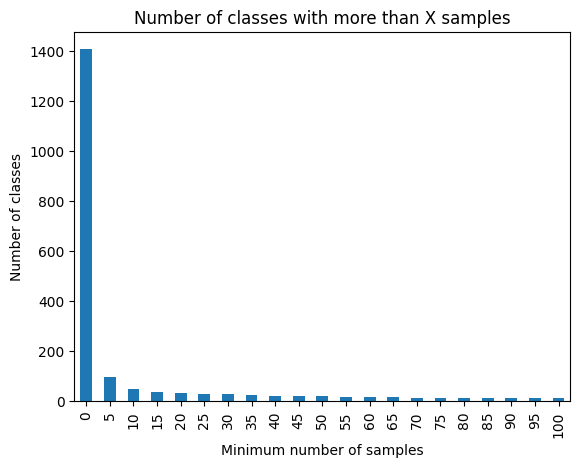

In [8]:
rule_counts = train_data["lemma_rule"].value_counts()

limits = range(0, 101, 5)

values = []

for limit in limits:
    count = (rule_counts >= limit).sum()
    values.append((limit, count))

plot_df = pd.DataFrame(values, columns=['limit', 'count'])

plot_df.plot(
    x='limit',
    y='count',
    kind='bar',
    title='Number of classes with more than X samples',
    xlabel='Minimum number of samples',
    ylabel='Number of classes',
    legend=False
)

display(plot_df)

# we will use the lemma_rules that have at least 10 samples. This will reduce the number of classes to 49. if we uses the full dataset we have 1,408 classes inducing alot of noise due to the low number of samples for many classes.

#### Result of the frequency filter

For the rest of the notebook, we keep only rules that appear **at least 10 times** in the training data. This reduces the classification problem from **1,408 to 49 rule classes**, giving each retained class enough examples to be learned more reliably. The filter itself is applied in the first lines of the next cell.

This choice also introduces a trade-off: rules removed at this stage cannot be predicted by the trained models. For this reason, rule coverage on the test set will be examined in the following section.


### 3.5 Train/test overlap and the generalization gap

Before evaluating the models, it is useful to understand how much overlap exists between the training and test sets. In particular, if most test words have already been seen during training, a dictionary-based approach could perform well simply by memorizing them.

After applying the rule-frequency filter from Section 3.4, we therefore measure three types of overlap:

1. **Shared tokens** — test tokens that also appear in the training set. These are the cases that can potentially be handled directly by the dictionary lemmatizer.

2. **Shared rules** — test examples whose lemma rule is among the rules retained in the training set. A rule-based classifier can only predict transformations that were available during training.

3. **Generalization subset** — test examples where the **token has never been seen during training, but its lemma rule has**. 

The third group is particularly important because it measures actual generalization to new words. A dictionary cannot directly retrieve the lemma of these unseen tokens, while a rule-based model can still predict a transformation it learned from other words.

This **generalization subset** is therefore used later to compare the learned models under the same conditions.



In [9]:
train_data = train_data[
    train_data['lemma_rule'].isin(
        rule_counts[rule_counts >= 10].index
    )
]


print(f'0. Number of unique lemma rules in training data after filtering: {train_data["lemma_rule"].nunique()}')
# ---------------------------------
# Shared tokens between train and test
# ---------------------------------
train_tokens = set(train_data['token'].unique())
test_tokens = set(test_data['token'].unique())

shared_tokens = train_tokens.intersection(test_tokens)

print(
    f'1. Number of shared tokens between train and test: {len(shared_tokens)} '
    f'is equal to {len(shared_tokens) / len(test_tokens) * 100:.2f}% '
    f'of the test tokens'
)

# ---------------------------------
# Shared rules between train and test
# ---------------------------------
train_rules = set(train_data['lemma_rule'].unique())
test_rules = set(test_data['lemma_rule'].unique())

shared_rules = train_rules.intersection(test_rules)

print(
    f'2. Number of shared rules between train and test: {len(shared_rules)} '
    f'is equal to {len(shared_rules) / len(test_rules) * 100:.2f}% '
    f'of the test rules and {len(shared_rules) / len(train_rules) * 100:.2f}% of the train rules'
)

# ---------------------------------
# Test samples with tokens NOT seen in train
# but with rules seen in train
# ---------------------------------
test_unseen_tokens_known_rules = test_data[
    (~test_data['token'].isin(train_tokens)) &
    (test_data['lemma_rule'].isin(train_rules))
].copy()

print(
    f'3. Number of test samples with unseen tokens but known rules: '
    f'{len(test_unseen_tokens_known_rules)}'
)



0. Number of unique lemma rules in training data after filtering: 49
1. Number of shared tokens between train and test: 3124 is equal to 76.31% of the test tokens
2. Number of shared rules between train and test: 47 is equal to 15.82% of the test rules and 95.92% of the train rules
3. Number of test samples with unseen tokens but known rules: 874


#### Distribution of the retained rules

The chart below shows the ten most frequent rules after filtering. The identity rule `0|+` (token already equal to its lemma) accounts for **more than half** of the training rows. It is followed by `-1|+` (removal of one final letter, typically plural *-s* or feminine *-e*) and by a group of verb rules that rebuild an infinitive in *-er* (`-3|+er`, `-2|+er`, `-1|+er`), as in *négociées*, *négociée*, *négocié* → *négocier*.

This strong imbalance is why the following sections use **balanced accuracy** and a class-weighted loss for the LSTM.

<Axes: title={'center': 'Top 10 lemma rules in training data'}, xlabel='Lemma Rule', ylabel='Count'>

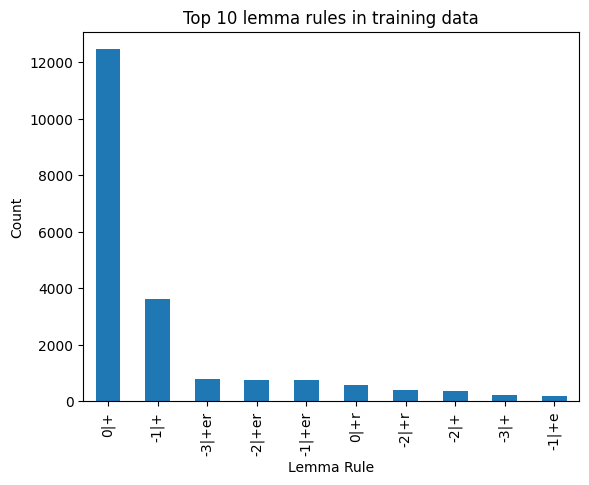

In [10]:
train_data['lemma_rule'].value_counts().head(10).plot(
    kind='bar',
    title='Top 10 lemma rules in training data',
    xlabel='Lemma Rule',
    ylabel='Count',
    legend=False
)

### Summary of Section 3

| Step | Result |
|---|---|
| Lowercasing | Train, test and Gallica share the same casing |
| Deduplication (train only) | 261,389 → 23,573 rows (−91.0%), 14,923 distinct lemmas |
| Lemmas → edit rules | 14,923 lemmas → 1,408 rules in train (297 rules in test) |
| Keep rules with ≥ 10 examples | 1,408 → **49 classes**|
| Train/test overlap | 76.3% of the unique test tokens are seen in training; 47 of the 49 retained rules appear in the test set |
| Generalization subset | **874 test rows** with an unseen token but a known rule |

**Takeaways**

- The train/test overlap is high, so a pure **memorization** approach (Section 4) should already perform well.
- The rules are **highly imbalanced** (`0|+` > 50% of the rows), hence balanced accuracy and class weights later on.


---

## 4. Baseline: dictionary-based lemmatizers

We begin with the simplest approach: a dictionary-based lemmatizer. During training, it stores the lemma associated with each token and, at prediction time, retrieves it whenever the same token appears again.

This approach does not learn any general transformation between words and lemmas. It works well for words that were already seen in the training data, but it cannot naturally handle new words.

For this reason, the dictionary provides a useful baseline: it shows how far we can get using memorization alone, before introducing models designed to generalize to unseen tokens.




### 4.1 Frequency-based dictionary (no POS input)


In the first version, the **token itself is used as the dictionary key**. Since the same word form can sometimes correspond to different lemmas, the model resolves these ambiguous cases using their frequency in the training data.

For each token, it counts how often it appears with each possible lemma and stores the most frequent one.

- **`fit(data)`** builds the dictionary and selects the most frequent lemma associated with each token.
- **`predict(token_list)`** looks up each token and returns its stored lemma. If the token was not seen during training, it returns `<UNK>`.

This means that the model can handle previously seen words, including ambiguous ones by choosing their most frequent interpretation, but it cannot generalize to new tokens.



In [11]:
class dictionary_lemmatizer:

    def __init__(self):
        self.dictionary = {}

    def fit(self, data):

        data = data.copy()

        data["token"] = data["token"].str.lower()
        data["lemma"] = data["lemma"].str.lower()

        # Count frequency of each token -> lemma pair
        grouped = (data.groupby(["token", "lemma"]).size().reset_index(name="frequency"))

        self.dictionary = {}

        for _, row in grouped.iterrows():

            token = row["token"]
            lemma = row["lemma"]
            frequency = row["frequency"]

            # First occurrence
            if token not in self.dictionary:

                self.dictionary[token] = {
                    "lemma": lemma,
                    "frequency": frequency
                }

            # If several lemmas exist for the same token,
            # choose the most frequent one
            else:

                if frequency > self.dictionary[token]["frequency"]:

                    self.dictionary[token] = {
                        "lemma": lemma,
                        "frequency": frequency
                    }

        return self

    def predict(self, token_list):

        predictions = []

        for token in token_list:

            token_lower = token.lower()

            if token_lower in self.dictionary:

                predictions.append(
                    self.dictionary[token_lower]["lemma"]
                )

            else:

                predictions.append("<UNK>")

        return predictions


#### Evaluation

The dictionary is fitted on `data_train_duplicates` (the copy kept before deduplication, so that token–lemma frequencies are preserved) and applied to the **full test set**. Two figures are reported, and the gap between them is the point of the experiment:

* **overall lemma accuracy**: over every test row, including out-of-vocabulary words that can only return `<UNK>`.
* **accuracy restricted to tokens present in the dictionary**: the quality of the lookup itself, once coverage is set aside. Any remaining error here is an  ambiguity of the frequency method

In [12]:
model_dictionary = dictionary_lemmatizer()
model_dictionary.fit(data_train_duplicates)

# We will use the test set to evaluate the performance of the dictionary lemmatizer. 
# The test set contains tokens that are not present in the training set.
# This model is not capable of predicting the lemma for unseen tokens, so we will use it as a baseline for our hybrid model.

tokens = test_data['token'].tolist()
predictions = model_dictionary.predict(tokens)

predictions_df = pd.DataFrame({
    "token": test_data["token"],
    'lemma_real': test_data["lemma"],
    "lemma_pred": predictions
})

accuracy = (predictions_df['lemma_real'] == predictions_df['lemma_pred']).mean()
print(f'Accuracy of the dictionary lemmatizer on the test set: {accuracy:.4f}')

# for words that are in the dictionary, the accuracy must be higher but in this case he have a problem that is based on frequency of the lemma in the training set. not the pos

tokens_in_dict = predictions_df[predictions_df['lemma_pred'] != "<UNK>"]
accuracy_in_dict = (tokens_in_dict['lemma_real'] == tokens_in_dict['lemma_pred']).mean()
print(f'Accuracy of the dictionary lemmatizer on tokens present in the dictionary: {accuracy_in_dict:.4f}')

Accuracy of the dictionary lemmatizer on the test set: 0.9156
Accuracy of the dictionary lemmatizer on tokens present in the dictionary: 0.9699


### 4.2 Dictionary with POS input

The second version also uses the **POS tag** when performing the lookup. Instead of storing a lemma for each token, the dictionary uses the pair `(token, POS)` as its key. This helps with ambiguous words that can have different lemmas depending on their grammatical role. For example, the same word form may appear as both a noun and a verb and can therefore be associated with a different lemma for each POS category. The trade-off is that the lookup becomes more specific: the model can only return a lemma if that exact `(token, POS)` combination was seen during training. Otherwise, it returns `<UNK>`.

In [13]:
class dictionary_lemmatizer_PoS:

    def __init__(self):
        self.dictionary = {}

    def fit(self, data):

        data = data.copy()

        data["token"] = data["token"].str.lower()
        data["lemma"] = data["lemma"].str.lower()
        data["pos"] = data["pos"].str.lower()

        # Count frequency of each token -> PoS -> lemma
        grouped = (data.groupby(["token", "lemma", "pos"]).size().reset_index(name="frequency"))

        self.dictionary = {}

        for _, row in grouped.iterrows():

            token = row["token"]
            lemma = row["lemma"]
            pos = row["pos"]

            # First occurrence
            if token not in self.dictionary:
                
                self.dictionary[token] = {pos:lemma}

            # If several lemmas exist for the same token,
            # choose the most frequent one
            else:
                self.dictionary[token][pos] = lemma


        return self

    def predict(self, token_list,pos_list):

        predictions = []

        for token,pos in zip(token_list,pos_list):

            token_lower = token.lower()

            if token_lower in self.dictionary:
                if pos in self.dictionary[token_lower]:
                    predictions.append(self.dictionary[token_lower][pos])
                else:
                    predictions.append("<UNK>")
            else:
                predictions.append("<UNK>")
    
        return predictions

#### Evaluation

Same protocol as in 4.1: the dictionary is fitted on `data_train_duplicates` and applied to the **full test set**, now using the `(token, POS)` pair as key.

* **overall lemma accuracy**: over every test row, including out-of-vocabulary words that can only return `<UNK>`.
* **accuracy restricted to tokens present in the dictionary**: the quality of the lookup itself, once coverage is set aside.

In [ ]:
model_dictionary = dictionary_lemmatizer_PoS()
model_dictionary.fit(data_train_duplicates)

# We will use the test set to evaluate the performance of the dictionary lemmatizer. 
# The test set contains tokens that are not present in the training set.


tokens = test_data['token'].tolist()
pos = test_data['pos'].tolist()
predictions = model_dictionary.predict(tokens, pos)

predictions_df = pd.DataFrame({
    "token": test_data["token"],
    'lemma_real': test_data["lemma"],
    "lemma_pred": predictions
})

accuracy = (predictions_df['lemma_real'] == predictions_df['lemma_pred']).mean()
print(f'Accuracy of the dictionary lemmatizer on the test set: {accuracy:.4f}')

# for words that are in the dictionary, the accuracy must be higher

tokens_in_dict = predictions_df[predictions_df['lemma_pred'] != "<UNK>"]
accuracy_in_dict = (tokens_in_dict['lemma_real'] == tokens_in_dict['lemma_pred']).mean()
print(f'Accuracy of the dictionary lemmatizer on tokens present in the dictionary: {accuracy_in_dict:.4f}')

Accuracy of the dictionary lemmatizer on the test set: 0.7606
Accuracy of the dictionary lemmatizer on tokens present in the dictionary: 0.8279


### Summary of Section 4

| Dictionary | Key | Lemma accuracy (full test) | Accuracy on found tokens | Coverage* |
|---|---|---|---|---|
| 4.1 Frequency-based | token | **0.9156** | 0.9699 | ≈ 94.4% |
| 4.2 With POS | (token, POS) | 0.7606 | 0.8279 | ≈ 91.9% |

\* Share of test rows found in the dictionary, derived as overall accuracy / accuracy on found tokens (a `<UNK>` prediction is always wrong).

**Takeaways**

- Memorization alone reaches **0.9156**: most test occurrences are frequent words already seen in training.
- Its limit is **coverage**: the ≈ 5.6% of test occurrences that were never seen are always wrong. This is what the learned models of Sections 5–7 try to fix.
- Using the POS tag as part of the key **lowers** performance.
- The frequency dictionary of 4.1 is therefore the baseline to beat, and the dictionary component reused in the best hybrid model (Section 8.5).

---

## 5. Machine-learning approaches

Unlike the dictionary-based approach, a machine-learning model can potentially handle words that were not seen during training. Instead of memorizing individual token–lemma pairs, the goal is to learn common patterns in how French words are transformed into their lemmas.

Using the edit-rule representation introduced in Section 3, lemmatization can now be treated as a **classification problem**. Given a token, the model predicts one of the 49 retained lemma rules. The predicted rule can then be applied to the token to obtain its lemma.

For example, if the model has learned that words with a particular ending often follow the rule `-2|+er`, it can apply this transformation to a new word even if that exact token was not present in the training set.

We explore models using the **characters of the token** as input, both with and without additional **POS information**.

The diagram below summarizes the different input representations and model families considered in the notebook.


```mermaid
flowchart TD
    A["Token (+ POS tag in 5.2 and 7)"]

    A --> B["Character n-grams (1-3), TF-IDF<br/>+ one-hot POS"]
    A --> D["Sequence of character indices<br/>+ POS symbol first"]

    B --> H["Classical ML: LogReg / SVC / KNN / Tree<br/>(Section 5)"]
    D --> J["Character embeddings + LSTM<br/>(Sections 6-7)"]

    H --> K["Predicted rule class (49 classes)"]
    J --> K

    K --> L["apply_lemma_rule(token, rule)"]
    L --> M[Lemma]
```

Both branches are explored: the **character n-grams → classical ML** branch in this section
(Section 5), and the **character embeddings → LSTM** branch in Sections 6 and 7. Each is run
twice, once with the token alone and once with the POS tag added, so the contribution of the
grammatical signal can be isolated in both settings.

### 5.1 Character n-grams + classical classifiers


Each token is represented using **character n-grams of length 1 to 3**, weighted with TF-IDF (`TfidfVectorizer(analyzer="char", ngram_range=(1,3))`).

This provides a simple way of capturing recurring character patterns within words without relying on pretrained embeddings. These short sequences can contain useful morphological information and help the models associate particular word patterns with the lemma rules introduced earlier.

Using this representation, we compare four standard classification algorithms:

- **Logistic Regression**
- **Support Vector Classifier (SVC)**
- **K-Nearest Neighbors (KNN)**
- **Decision Tree**

Each model is evaluated using **5-fold stratified cross-validation**. Stratification ensures that the distribution of lemma-rule classes is preserved as much as possible across the folds, which is particularly important because the classes are imbalanced.

Performance is measured on both the training and validation folds. Comparing these results also helps identify whether a model is generalizing well or overfitting the training data.




In [15]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

# linear models
from sklearn.linear_model import LogisticRegression
# Super vector machine
from sklearn.svm import SVC
# Tree based model
from sklearn.tree import DecisionTreeClassifier
# KNN
from sklearn.neighbors import KNeighborsClassifier


from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score, balanced_accuracy_score



#### Inputs and label encoding

The models use the `token` column as input and the corresponding `lemma_rule` as the target. Since the classifiers expect numerical class labels, the lemma rules are converted to integer values using a `LabelEncoder`.

A shared **5-fold StratifiedKFold** is also created for cross-validation. The data is shuffled before splitting, while a fixed `random_state` ensures that every classifier is evaluated using the same folds. Stratification helps preserve the distribution of lemma-rule classes across the different splits.

The following cell prepares these inputs and reports the number of training examples and rule classes used in the experiments


In [16]:

models_eval = {
    "Logistic Regression": LogisticRegression(max_iter=1000, n_jobs=-1),
    "SVC": SVC(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier()
}


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

X = train_data['token']
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(train_data['lemma_rule'])

len(y), len(label_encoder.classes_)

(21630, 49)

#### Cross-validated comparison (token only)

Each classifier is wrapped in a `Pipeline` with the TF-IDF vectorizer  so the vocabulary is
re-fitted inside every fold and no information leaks from validation to training  and
evaluated with `cross_validate` using **balanced accuracy** (`scoring="balanced_accuracy"`).
The columns of the table are named *Accuracy* for brevity, but they contain balanced accuracy.

Results are collected into a table reporting mean and standard deviation of train and
validation accuracy, the gap between them, and a custom **Stability Score**:

```
Stability Score = Val Mean − 0.5 × (Train Mean − Val Mean) − 1.0 × Val Std
```

which penalises both overfitting and fold-to-fold variance, so that the ranking rewards models
that are good *and* reliable rather than merely good on average. The table is sorted by that
score and saved to `results/Default_results_models_ML_ngrams.csv`.

In [17]:
X = train_data['token']
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(train_data['lemma_rule'])

results = []

for classifier in models_eval:

    print(f"Training {classifier}...")

    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            analyzer="char",
            ngram_range=(1, 3)
        )),
        ("classifier", models_eval[classifier])
    ])

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring="balanced_accuracy",
        return_train_score=True,
        n_jobs=-1,
        verbose=2
    )

    train_mean = scores["train_score"].mean()
    train_std = scores["train_score"].std()

    val_mean = scores["test_score"].mean()
    val_std = scores["test_score"].std()

    results.append({
        "Model": classifier,
        "Train Mean Accuracy": train_mean,
        "Train Std Accuracy": train_std,
        "Val Mean Accuracy": val_mean,
        "Val Std Accuracy": val_std,
        "Gap": train_mean - val_mean
    })


df_results_models = pd.DataFrame(results)
df_results_models['Stability Score'] = df_results_models.apply( lambda x: x['Val Mean Accuracy'] - 0.5 * (x['Train Mean Accuracy'] - x['Val Mean Accuracy']) - 1.0 * x['Val Std Accuracy'],axis=1)
df_results_models = df_results_models.sort_values(by='Stability Score', ascending=False)
df_results_models.to_csv("results/Default_results_models_ML_ngrams.csv", index=False)
df_results_models

Training Logistic Regression...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


[CV] END .................................................... total time=   4.5s
[CV] END .................................................... total time=   4.6s
[CV] END .................................................... total time=   4.6s
[CV] END .................................................... total time=   4.9s
[CV] END .................................................... total time=   5.0s
Training SVC...


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    7.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


[CV] END .................................................... total time=  51.9s
[CV] END .................................................... total time=  50.7s
[CV] END .................................................... total time=  50.6s
[CV] END .................................................... total time=  52.1s
[CV] END .................................................... total time=  51.3s
Training KNN...


...

[CV] END .................................................... total time=   3.2s
[CV] END .................................................... total time=   3.2s
[CV] END .................................................... total time=   3.2s
[CV] END .................................................... total time=   3.2s
[CV] END .................................................... total time=   2.0s
Training Decision Tree...


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   14.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


[CV] END .................................................... total time=   2.9s
[CV] END .................................................... total time=   3.0s
[CV] END .................................................... total time=   3.1s
[CV] END .................................................... total time=   3.2s
[CV] END .................................................... total time=   3.2s


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    3.5s finished


,Model,Train Mean Accuracy,Train Std Accuracy,Val Mean Accuracy,Val Std Accuracy,Gap,Stability Score
1,SVC,0.664075,0.010012,0.398997,0.010990,0.265077,0.255469
0,Logistic Regression,0.295285,0.008017,0.222408,0.014345,0.072877,0.171625
3,Decision Tree,0.963414,0.004036,0.446662,0.025620,0.516752,0.162666
2,KNN,0.487122,0.013309,0.271011,0.038288,0.216111,0.124667


### Interpretation of results (default hyperparameters)
- **All models overfit**: training scores are well above validation scores. 
- The Decision Tree has the highest validation mean (0.446) but also the largest gap (0.516). The **SVC** comes second on validation (0.399) with a smaller gap, and is ranked **first by Stability Score** (0.265).
- Logistic Regression has the smallest gap (0.073). KNN is both weak (0.271) and the least stable across folds (std 0.038).

These results use default hyperparameters; the next step tunes them.

#### Hyper-parameter search (token only)

After the initial comparison, we tune the hyperparameters of each classifier to find a more suitable configuration for the task. Each model is tested with several combinations of its main hyperparameters, using the same **5-fold stratified cross-validation** setup as before.

The search includes parameters such as the regularization strength for Logistic Regression, the kernel and `C` value for SVC, the number of neighbours for KNN, and the depth and splitting criteria of the Decision Tree.

Rather than selecting a configuration based only on validation balanced accuracy, we use the custom `stable_refit` criterion which  applies the same Stability Score as above.

The ten best configurations of each model are saved to `results/Only_ngrams_grid_search_top10_results.yaml` (they are not displayed in the notebook).

In [18]:
# use of GridSearchCV to find the best hyperparameters for the models
import yaml
import numpy as np

# Define the parameter grid for each model
param_grids = {

    "Logistic Regression": {
        "classifier__C": [0.1, 0.5, 1, 2, 5, 10],
        "classifier__penalty": ["l2"],
        "classifier__solver": ["lbfgs", "saga"]
    },

    "SVC": {
        "classifier__C": [0.1, 0.5, 1, 2, 5, 10],
        "classifier__kernel": ["linear", "rbf"],
    },

    "KNN": {
        "classifier__n_neighbors": [3, 5, 7, 10],
    },

    "Decision Tree": {
        "classifier__max_depth": [10, 20, 30],
        "classifier__min_samples_split": [2, 5, 10]
    }
}


results = {}


def stable_scores(cv_results):
    LAMBDA = 0.5
    GAMMA = 1.0
    train_mean = cv_results["mean_train_score"]
    val_mean = cv_results["mean_test_score"]
    val_std = cv_results["std_test_score"]

    gap = np.abs(train_mean - val_mean)

    return (
        val_mean
        - LAMBDA * gap
        - GAMMA * val_std
    )


def stable_refit(cv_results):
    scores = stable_scores(cv_results)
    return np.argmax(scores)


for classifier in models_eval:

    print(f"\nPerforming grid search for {classifier}...")

    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            analyzer="char",
            ngram_range=(1, 3)
        )),
        ("classifier", models_eval[classifier])
    ])

    grid_search = GridSearchCV(
        pipeline,
        param_grids[classifier],
        cv=cv,
        scoring="balanced_accuracy",
        n_jobs=-1,
        return_train_score=True,
        refit=stable_refit,
        verbose=2
    )

    grid_search.fit(X, y)

    # ----------------------------------
    # Get the 10 best configurations
    # ----------------------------------

    stable_score = stable_scores(grid_search.cv_results_)

    top_10_indices = np.argsort(stable_score)[::-1][:10]

    top_10_results = []

    for rank, idx in enumerate(top_10_indices, start=1):

        model_result = {
            "rank": rank,

            "params": grid_search.cv_results_["params"][idx],

            "stable_score": float(stable_score[idx]),

            "Avg_train_score": float(
                grid_search.cv_results_["mean_train_score"][idx]
            ),

            "Std_train_score": float(
                grid_search.cv_results_["std_train_score"][idx]
            ),

            "Avg_test_score": float(
                grid_search.cv_results_["mean_test_score"][idx]
            ),

            "Std_test_score": float(
                grid_search.cv_results_["std_test_score"][idx]
            )
        }

        top_10_results.append(model_result)

    results[classifier] = top_10_results



with open(
    "results/Only_ngrams_grid_search_top10_results.yaml",
    "w"
) as file:

    yaml.safe_dump(
        results,
        file,
        sort_keys=False
    )


Performing grid search for Logistic Regression...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END classifier__C=0.1, classifier__penalty=l2, classifier__solver=saga; total time=   1.2s
[CV] END classifier__C=0.1, classifier__penalty=l2, classifier__solver=saga; total time=   1.2s
[CV] END classifier__C=0.1, classifier__penalty=l2, classifier__solver=saga; total time=   1.3s
[CV] END classifier__C=0.1, classifier__penalty=l2, classifier__solver=lbfgs; total time=   2.4s
[CV] END classifier__C=0.1, classifier__penalty=l2, classifier__solver=lbfgs; total time=   2.5s
[CV] END classifier__C=0.1, classifier__penalty=l2, classifier__solver=saga; total time=   1.3s
[CV] END classifier__C=0.1, classifier__penalty=l2, classifier__solver=saga; total time=   1.4s
[CV] END classifier__C=0.1, classifier__penalty=l2, classifier__solver=lbfgs; total time=   2.8s
[CV] END classifier__C=0.1, classifier__penalty=l2, classifier__solver=lbfgs; total time=   2.8s
[CV] END classifier_

/Users/fserracrespi/Desktop/Paris Saclay/NLP Today/Workshops/.env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END classifier__C=0.5, classifier__penalty=l2, classifier__solver=saga; total time=   4.0s
[CV] END classifier__C=0.5, classifier__penalty=l2, classifier__solver=saga; total time=   3.6s
[CV] END classifier__C=0.5, classifier__penalty=l2, classifier__solver=saga; total time=   3.7s
[CV] END classifier__C=0.5, classifier__penalty=l2, classifier__solver=saga; total time=   4.0s
[CV] END classifier__C=1, classifier__penalty=l2, classifier__solver=lbfgs; total time=   5.5s
[CV] END classifier__C=1, classifier__penalty=l2, classifier__solver=lbfgs; total time=   5.6s
[CV] END classifier__C=1, classifier__penalty=l2, classifier__solver=lbfgs; total time=   5.6s
[CV] END classifier__C=1, classifier__penalty=l2, classifier__solver=lbfgs; total time=   6.1s
[CV] END classifier__C=1, classifier__penalty=l2, classifier__solver=lbfgs; total time=   6.0s
[CV] END classifier__C=1, classifier__penalty=l2, classifier__solver=saga; total time=   6.1s
[CV] END classifier__C=1, classifier__penalty=l

/Users/fserracrespi/Desktop/Paris Saclay/NLP Today/Workshops/.env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END .......classifier__C=0.5, classifier__kernel=linear; total time=  42.5s
[CV] END .......classifier__C=0.5, classifier__kernel=linear; total time=  43.1s
[CV] END ..........classifier__C=0.5, classifier__kernel=rbf; total time= 1.0min
[CV] END ..........classifier__C=0.5, classifier__kernel=rbf; total time= 1.0min
[CV] END ..........classifier__C=0.5, classifier__kernel=rbf; total time= 1.0min
[CV] END ..........classifier__C=0.5, classifier__kernel=rbf; total time= 1.0min
[CV] END ..........classifier__C=0.5, classifier__kernel=rbf; total time= 1.0min
[CV] END .........classifier__C=1, classifier__kernel=linear; total time=  37.4s
[CV] END .........classifier__C=1, classifier__kernel=linear; total time=  36.5s
[CV] END .........classifier__C=1, classifier__kernel=linear; total time=  37.1s
[CV] END .........classifier__C=1, classifier__kernel=linear; total time=  39.1s
[CV] END .........classifier__C=1, classifier__kernel=linear; total time=  39.5s
[CV] END ............classif

/Users/fserracrespi/Desktop/Paris Saclay/NLP Today/Workshops/.env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END ..........................classifier__n_neighbors=3; total time=   8.2s
[CV] END ..........................classifier__n_neighbors=3; total time=   8.1s
[CV] END ..........................classifier__n_neighbors=3; total time=   8.1s
[CV] END ..........................classifier__n_neighbors=3; total time=   8.2s
[CV] END ..........................classifier__n_neighbors=3; total time=   8.2s
[CV] END ..........................classifier__n_neighbors=7; total time=   2.5s
[CV] END ..........................classifier__n_neighbors=7; total time=   2.5s
[CV] END ..........................classifier__n_neighbors=7; total time=   2.6s
[CV] END ..........................classifier__n_neighbors=7; total time=   2.7s
[CV] END ..........................classifier__n_neighbors=7; total time=   2.6s
[CV] END .........................classifier__n_neighbors=10; total time=   2.7s
[CV] END .........................classifier__n_neighbors=10; total time=   2.9s
[CV] END ...................

#### Final model and generalization test (token only)

Cross-validation shows how well the model performs on different splits of the training data, but we are also interested in its ability to handle **words that were never seen during training**.

For this final evaluation, we use the best configuration found during the hyperparameter search: an **SVC with a linear kernel and C = 5**. The model is trained again using the entire filtered training set.

It is then evaluated on the **generalization subset** defined in Section 3.5. This subset contains test words that were not present in the training data, but whose lemma rule was available during training. These are precisely the cases where a rule-based model has the opportunity to generalize beyond simple dictionary lookup.

Performance is measured using **rule balanced accuracy**, comparing the predicted lemma rule with the correct one.

The same subset and evaluation metric are later used for the LSTM models, allowing the classical machine-learning and neural approaches to be compared under the same conditions.

In [19]:
# generalization test on the test set including tokens in the dictionary and tokens not in the dictionary but with rules seen in the training set
from sklearn.metrics import balanced_accuracy_score
test_data_generalization = test_data[~test_data['token'].isin(train_data['token']) & (test_data['lemma_rule'].isin(train_data['lemma_rule']))]


X_train = train_data['token']
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_data['lemma_rule'])

print(f"Train shape: {X_train.shape[0]}")
pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            analyzer="char",
            ngram_range=(1, 3)
        )),
        ("classifier",SVC(C=5, kernel='linear', gamma='scale')) # best model from the grid search
    ])

pipeline.fit(X_train, y_train)


print(f"Test shape: {test_data_generalization.shape[0]}")

X_test = test_data_generalization['token']
predictions = pipeline.predict(X_test)

predictions_decoded = label_encoder.inverse_transform(predictions)

df_results = pd.DataFrame({
    "token": test_data_generalization["token"],
    "lemma_real": test_data_generalization["lemma"],
    "lemma_rule_real": test_data_generalization["lemma_rule"],
    "lemma_rule_pred": predictions_decoded})

balanced_accuracy = balanced_accuracy_score(
    df_results["lemma_rule_real"],
    df_results["lemma_rule_pred"]
)

print(f"Balanced Accuracy: {balanced_accuracy:.4f}")

Train shape: 21630
Test shape: 874
Balanced Accuracy: 0.7229


/Users/fserracrespi/Desktop/Paris Saclay/NLP Today/Workshops/.env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


**Result.** The tuned SVC (linear kernel, C = 5) reaches a rule balanced accuracy of **0.7229** on the 874-row generalization subset.



### 5.2 Character n-grams + POS tag

The previous models rely only on the spelling of each token. However, some words can have different lemmas depending on their grammatical role, so character information alone may not always be enough.

To include this additional information, the **POS tag** is added as a second input feature. The token is still represented using character n-grams, while the POS tag is one-hot encoded. Both representations are then combined using a `ColumnTransformer`.

The same four classifiers and the same cross-validation setup from Section 5.1 are used. Keeping the rest of the pipeline unchanged allows us to examine whether adding POS information improves the prediction of lemma rules.

The resulting training and validation scores, together with the train-validation gap and Stability Score, are saved to `results/Default_results_models_ML_ngrams_PoS.csv`.



In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

X = train_data[['token','pos']]
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(train_data['lemma_rule'])

results = []

preprocessor = ColumnTransformer([
    
    # token -> character n-grams
    ("token_tfidf", TfidfVectorizer(
        analyzer="char",
        ngram_range=(1, 3)
    ), "token"),

    # pos -> categorical encoding
    ("pos", OneHotEncoder(
        handle_unknown="ignore"
    ), ["pos"])

])

for classifier in models_eval:

    print(f"Training {classifier}...")

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", models_eval[classifier])
    ])

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring="balanced_accuracy",
        return_train_score=True,
        n_jobs=-1,
        verbose=2
    )

    train_mean = scores["train_score"].mean()
    train_std = scores["train_score"].std()

    val_mean = scores["test_score"].mean()
    val_std = scores["test_score"].std()

    results.append({
        "Model": classifier,
        "Train Mean Accuracy": train_mean,
        "Train Std Accuracy": train_std,
        "Val Mean Accuracy": val_mean,
        "Val Std Accuracy": val_std,
        "Gap": train_mean - val_mean
    })


df_results_models = pd.DataFrame(results)
df_results_models['Stability Score'] = df_results_models.apply( lambda x: x['Val Mean Accuracy'] - 0.5 * (x['Train Mean Accuracy'] - x['Val Mean Accuracy']) - 1.0 * x['Val Std Accuracy'],axis=1)
df_results_models = df_results_models.sort_values(by='Stability Score', ascending=False)

df_results_models.to_csv("results/Default_results_models_ML_ngrams_PoS.csv", index=False)
df_results_models

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


Training Logistic Regression...
[CV] END .................................................... total time=   5.2s
[CV] END .................................................... total time=   5.3s
[CV] END .................................................... total time=   5.3s
[CV] END .................................................... total time=   5.4s
[CV] END .................................................... total time=   5.8s
Training SVC...


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    6.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


[CV] END .................................................... total time=  40.8s
[CV] END .................................................... total time=  40.8s
[CV] END .................................................... total time=  40.6s
[CV] END .................................................... total time=  41.0s
[CV] END .................................................... total time=  41.0s
Training KNN...


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  1.2min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


[CV] END .................................................... total time=   2.2s
[CV] END .................................................... total time=   2.2s
[CV] END .................................................... total time=   2.2s
[CV] END .................................................... total time=   2.2s
[CV] END .................................................... total time=   2.3s
Training Decision Tree...


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   11.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


[CV] END .................................................... total time=   2.3s
[CV] END .................................................... total time=   2.2s
[CV] END .................................................... total time=   2.3s
[CV] END .................................................... total time=   2.4s
[CV] END .................................................... total time=   2.4s


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    5.4s finished


,Model,Train Mean Accuracy,Train Std Accuracy,Val Mean Accuracy,Val Std Accuracy,Gap,Stability Score
3,Decision Tree,0.992520,0.001572,0.626462,0.022797,0.366058,0.420636
1,SVC,0.738973,0.010678,0.534271,0.015442,0.204702,0.416478
2,KNN,0.645275,0.005774,0.434814,0.021537,0.210461,0.308047
0,Logistic Regression,0.480393,0.008313,0.363809,0.015494,0.116583,0.290024


**Result.** Adding the POS tag improves the validation balanced accuracy of **every** model.

#### Hyper-parameter search (with POS)

The same grid search as in 5.1 is repeated on the POS-augmented pipelines, so the two
configurations are compared at their respective best rather than at their defaults. The ten
best configurations per model are written to
`results/PoS_ngrams_grid_search_top10_results.yaml`.

In [21]:

results = {}

for classifier in models_eval:
    print(f"Performing grid search for {classifier}...")

    pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("classifier", models_eval[classifier])
        ])

    grid_search = GridSearchCV(
        pipeline,
        param_grids[classifier],
        cv=cv,
        scoring="balanced_accuracy",
        n_jobs=-1,
        return_train_score=True,
        verbose=2
    )

    grid_search.fit(X, y)

    
    
    # ----------------------------------
    # Get the 10 best configurations
    # ----------------------------------

    stable_score = stable_scores(grid_search.cv_results_)

    top_10_indices = np.argsort(stable_score)[::-1][:10]

    top_10_results = []

    for rank, idx in enumerate(top_10_indices, start=1):

        model_result = {
            "rank": rank,

            "params": grid_search.cv_results_["params"][idx],

            "stable_score": float(stable_score[idx]),

            "Avg_train_score": float(
                grid_search.cv_results_["mean_train_score"][idx]
            ),

            "Std_train_score": float(
                grid_search.cv_results_["std_train_score"][idx]
            ),

            "Avg_test_score": float(
                grid_search.cv_results_["mean_test_score"][idx]
            ),

            "Std_test_score": float(
                grid_search.cv_results_["std_test_score"][idx]
            )
        }

        top_10_results.append(model_result)

    results[classifier] = top_10_results

with open(
    "results/PoS_ngrams_grid_search_top10_results.yaml",
    "w"
) as file:

    yaml.safe_dump(
        results,
        file,
        sort_keys=False
    )

Performing grid search for Logistic Regression...
Fitting 5 folds for each of 12 candidates, totalling 60 fits


[CV] END classifier__C=0.1, classifier__penalty=l2, classifier__solver=lbfgs; total time=   3.2s
[CV] END classifier__C=0.1, classifier__penalty=l2, classifier__solver=lbfgs; total time=   3.2s
[CV] END classifier__C=0.1, classifier__penalty=l2, classifier__solver=lbfgs; total time=   3.2s


/Users/fserracrespi/Desktop/Paris Saclay/NLP Today/Workshops/.env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END classifier__C=0.1, classifier__penalty=l2, classifier__solver=lbfgs; total time=   3.4s
[CV] END classifier__C=0.1, classifier__penalty=l2, classifier__solver=lbfgs; total time=   3.3s
[CV] END classifier__C=0.5, classifier__penalty=l2, classifier__solver=lbfgs; total time=   4.8s
[CV] END classifier__C=0.5, classifier__penalty=l2, classifier__solver=lbfgs; total time=   4.6s
[CV] END classifier__C=0.5, classifier__penalty=l2, classifier__solver=lbfgs; total time=   5.0s
[CV] END classifier__C=0.1, classifier__penalty=l2, classifier__solver=saga; total time=  12.1s
[CV] END classifier__C=0.1, classifier__penalty=l2, classifier__solver=saga; total time=  12.2s
[CV] END classifier__C=0.1, classifier__penalty=l2, classifier__solver=saga; total time=  12.3s
[CV] END classifier__C=0.1, classifier__penalty=l2, classifier__solver=saga; total time=  12.4s
[CV] END classifier__C=0.5, classifier__penalty=l2, classifier__solver=lbfgs; total time=   5.4s
[CV] END classifier__C=0.5, classi

/Users/fserracrespi/Desktop/Paris Saclay/NLP Today/Workshops/.env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END ..........classifier__C=0.5, classifier__kernel=rbf; total time=  52.3s
[CV] END ..........classifier__C=0.5, classifier__kernel=rbf; total time=  51.9s
[CV] END ..........classifier__C=0.5, classifier__kernel=rbf; total time=  52.2s
[CV] END ..........classifier__C=0.5, classifier__kernel=rbf; total time=  53.2s
[CV] END .........classifier__C=1, classifier__kernel=linear; total time=  31.0s
[CV] END .........classifier__C=1, classifier__kernel=linear; total time=  35.7s
[CV] END .........classifier__C=1, classifier__kernel=linear; total time=  36.1s
[CV] END .........classifier__C=1, classifier__kernel=linear; total time=  36.8s
[CV] END .........classifier__C=1, classifier__kernel=linear; total time=  36.0s
[CV] END ............classifier__C=1, classifier__kernel=rbf; total time=  51.7s
[CV] END ............classifier__C=1, classifier__kernel=rbf; total time=  52.8s
[CV] END ............classifier__C=1, classifier__kernel=rbf; total time=  53.3s
[CV] END ............classif

/Users/fserracrespi/Desktop/Paris Saclay/NLP Today/Workshops/.env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END ..........................classifier__n_neighbors=5; total time=   6.3s
[CV] END ..........................classifier__n_neighbors=5; total time=   6.3s
[CV] END ..........................classifier__n_neighbors=3; total time=   6.4s
[CV] END ..........................classifier__n_neighbors=3; total time=   6.6s
[CV] END ..........................classifier__n_neighbors=3; total time=   6.6s
[CV] END ..........................classifier__n_neighbors=3; total time=   6.5s
[CV] END ..........................classifier__n_neighbors=3; total time=   6.4s
[CV] END ..........................classifier__n_neighbors=7; total time=   2.7s
[CV] END ..........................classifier__n_neighbors=7; total time=   2.8s
[CV] END ..........................classifier__n_neighbors=7; total time=   2.7s
[CV] END .........................classifier__n_neighbors=10; total time=   3.2s
[CV] END ..........................classifier__n_neighbors=7; total time=   3.1s
[CV] END ...................

#### Final model and generalization test (with POS)

The counterpart of the test above for the POS-augmented pipeline, so that the effect of the POS
tag is measured on unseen words and not only in cross-validation.

* **Model:** the best configuration from the POS grid search: an **SVC with a linear kernel and C = 10** (see `results/PoS_ngrams_grid_search_top10_results.yaml`).
* **Evaluation set and metric:** identical to the token-only test (the same 874-row
  generalization subset, rule balanced accuracy), so the only thing that differs between the two figures
  is the presence of the POS feature.



In [22]:
# generalization test on the test set including tokens in the dictionary and tokens not in the dictionary but with rules seen in the training set
test_data_generalization = test_data[~test_data['token'].isin(train_data['token']) & (test_data['lemma_rule'].isin(train_data['lemma_rule']))]




X_train = train_data[['token', 'pos']]
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_data['lemma_rule'])

print(f"Train shape: {X_train.shape[0]}")

preprocessor = ColumnTransformer([
    
    # token -> character n-grams
    ("token_tfidf", TfidfVectorizer(
        analyzer="char",
        ngram_range=(1, 3)
    ), "token"),

    # pos -> categorical encoding
    ("pos", OneHotEncoder(
        handle_unknown="ignore"
    ), ["pos"])

])


pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier",SVC(C=10, kernel='linear')) # best model from the grid search
    ])

pipeline.fit(X_train, y_train)


print(f"Test shape: {test_data_generalization.shape[0]}")

X_test = test_data_generalization[['token', 'pos']]
predictions = pipeline.predict(X_test)

predictions_decoded = label_encoder.inverse_transform(predictions)

df_results = pd.DataFrame({
    "token": test_data_generalization["token"],
    "lemma_real": test_data_generalization["lemma"],
    "lemma_rule_real": test_data_generalization["lemma_rule"],
    "lemma_rule_pred": predictions_decoded})

balanced_accuracy = balanced_accuracy_score(
    df_results["lemma_rule_real"],
    df_results["lemma_rule_pred"]
)

print(f"Balanced Accuracy: {balanced_accuracy:.4f}")

Train shape: 21630
Test shape: 874
Balanced Accuracy: 0.9041


/Users/fserracrespi/Desktop/Paris Saclay/NLP Today/Workshops/.env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


### Summary of Section 5

**Cross-validation, default hyperparameters (validation balanced accuracy)**

| Model | Token only | Token + POS |
|---|---|---|
| SVC | 0.399 | 0.534 |
| Decision Tree | 0.458 | 0.617 |
| KNN | 0.271 | 0.435 |
| Logistic Regression | 0.222 | 0.364 |

*Token-only column: last complete run of the 5.1 cross-validation cell (see the note in 5.1).*

**Generalization subset (874 unseen tokens, rule balanced accuracy), tuned SVC**

| Input | Configuration | Score |
|---|---|---|
| Token only | SVC, linear, C = 5 | 0.7229 |
| Token + POS | SVC, linear, C = 10 | **0.9041** |

**Takeaways**

- Treating lemmatization as rule classification works: a linear SVC on character n-grams predicts the correct rule for most **unseen** words.
- The SVC offers the best trade-off between performance and overfitting.
- The **POS tag is very informative**: between +13.5 and +16.4 points in cross-validation and **+18 points** on unseen words. Which means that the same word ending can call for different rules depending on the category.


---

## 6. Sequence model: character-level LSTM (without POS)

The machine-learning models in the previous section represent each word using character n-grams. Although this captures useful local patterns, it does not explicitly preserve the position and order of those patterns within the word.

This is particularly relevant for lemmatization, where transformations often depend on the **ending of a word**. To better capture this sequential structure, we now introduce a **character-level LSTM**.

Instead of treating the token as a collection of character fragments, the LSTM processes its characters in order. Each character is first mapped to a learned embedding, and the sequence is then passed through the LSTM. The final representation is used to predict one of the same 49 lemma-rule classes.

The target classes and evaluation metric remain the same as in the previous section, allowing the LSTM to be compared with the classical machine-learning approaches.



### 6.1 Input encoding

Neural networks need fixed-size integer input, so the class below turns each token into a
sequence of character indices.

* **`fit(data)`** — builds the character vocabulary (plus the special symbols `<PAD>` and
  `<UNK>`), records the maximum token length, and fits a `LabelEncoder` on the rule classes.
* **`transform(data)`** — converts every token into a list of character indices, padded with
  `<PAD>` or truncated to that maximum length, and returns the encoded labels when the
  `lemma_rule` column is present (so the same method serves both training and inference).

Unseen characters map to `<UNK>`, which is what allows the model to accept words that contain
symbols absent from the training data.

In [23]:
class data_preprcessing_NO_PoS:

    def __init__(self):
        self.char_to_idx = None
        self.rule_to_idx = None
        self.max_token_length = None
        self.rule_transformation = None

    def fit(self, data):

        set_chars = set(["<UNK>", "<PAD>"])
        for token in data['token']:
            list_chars = list(token)
            set_chars.update(list_chars)

        self.char_to_idx = {char: idx for idx, char in enumerate(sorted(set_chars))}
        self.max_token_length = data['token'].apply(len).max()
        rule_transformer = LabelEncoder()
        self.rule_transformation = rule_transformer.fit(data['lemma_rule'])


        return self

    def transform(self, data):
            X = []
            y = []

            has_labels = "lemma_rule" in data.columns

            for _, row in data.iterrows():
                token_list = list(row['token'])

                # pading token to max_token_length
                if len(token_list) < self.max_token_length:
                    while len(token_list) < self.max_token_length:
                        token_list.append("<PAD>")

                if len(token_list) > self.max_token_length:
                    token_list = token_list[:self.max_token_length] # truncate the token if it exceeds max_token_length

                # convert token to indices
                token_indexes = []
                for char in token_list:
                    if char in self.char_to_idx:
                        token_indexes.append(self.char_to_idx[char])
                    else:
                        token_indexes.append(self.char_to_idx["<UNK>"])


                X.append(token_indexes)

                if has_labels:
                    y.append(self.rule_transformation.transform([row['lemma_rule']])[0])

            X = np.array(X)

            if has_labels:
                return X, np.array(y)

            return X


### 6.2 Model architecture

The LSTM model follows a simple sequence-classification architecture. Each character is first mapped to a learned embedding, and the resulting sequence is processed by a multi-layer LSTM. Dropout is applied before a final linear layer that produces one score for each possible lemma rule.

Because tokens have different lengths, shorter words are padded to form batches. The model uses `pack_padded_sequence` so that the LSTM only processes the actual characters of each token and ignores the padding when computing its final representation.

The `fit(...)` method trains the model in mini-batches using a **class-weighted** `CrossEntropyLoss` (each rule is weighted inversely to its frequency, to counter the dominance of `0|+`) and the Adam optimizer with weight decay for regularization. When validation data is provided, **early stopping** is also used: training stops if the validation loss does not improve for a given number of epochs, and the weights from the best epoch are restored.

Finally, `predict(...)` returns the predicted lemma-rule class for each input token.

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

class LSTM_lemmatizer_rule(nn.Module):

    def __init__(self, vocab_size, num_classes, embedding_dim=32, hidden_dim=64, padding_idx=0, num_layers=2):
        super().__init__()

        self.padding_idx = padding_idx

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=padding_idx
        )

        self.dropout = nn.Dropout(0.2)

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            num_layers=num_layers
        )

        

        self.fc = nn.Linear(
            in_features=hidden_dim,
            out_features=num_classes
        )

    def forward(self, x):
        # real length of each token (number of non-<PAD> characters),
        # needed so the LSTM stops at the last real character instead
        # of drifting through the trailing padding steps
        lengths = (x != self.padding_idx).sum(dim=1).clamp(min=1).cpu()

        x = self.embedding(x)

        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths, batch_first=True, enforce_sorted=False
        )

        _, (hidden, _) = self.lstm(packed)

        hidden = hidden[-1]

        hidden = self.dropout(hidden)

        logits = self.fc(hidden)

        return logits


    def fit(
    self,
    X_train,
    y_train,
    X_val=None,
    y_val=None,
    lr=0.001,
    epochs=50,
    batch_size=32,
    patience=5
):

        # Convert to tensors
        X_train = torch.tensor(X_train, dtype=torch.long)
        y_train = torch.tensor(y_train, dtype=torch.long)

        dataset = TensorDataset(X_train, y_train)

        dataloader = DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=True
        )

        # Validation tensors
        if X_val is not None:
            X_val = torch.tensor(X_val, dtype=torch.long)
            y_val = torch.tensor(y_val, dtype=torch.long)

        device = next(self.parameters()).device

        # ==========================
        # WEIGHTED CROSS ENTROPY
        # ==========================

        # Number of samples for each class
        class_counts = torch.bincount(y_train)

        # Balanced class weights:
        # n_samples / (n_classes * samples_in_class)
        class_weights = len(y_train) / (
            len(class_counts) * class_counts.float()
        )

        class_weights = class_weights.to(device)

        criterion = nn.CrossEntropyLoss(
            weight=class_weights
        )

        optimizer = torch.optim.Adam(
            self.parameters(),
            lr=lr,
            weight_decay=1e-4
        )

        # Early stopping variables
        best_val_loss = float("inf")
        epochs_without_improvement = 0
        best_state = None

        for epoch in range(epochs):

            # ==========================
            # TRAIN
            # ==========================
            self.train()

            total_loss = 0.0

            for X_batch, y_batch in dataloader:

                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                optimizer.zero_grad()

                logits = self(X_batch)

                loss = criterion(logits, y_batch)

                loss.backward()

                optimizer.step()

                total_loss += loss.item()

            train_loss = total_loss / len(dataloader)

            # ==========================
            # VALIDATION
            # ==========================
            if X_val is not None:

                self.eval()

                with torch.no_grad():

                    val_logits = self(X_val.to(device))

                    val_loss = criterion(
                        val_logits,
                        y_val.to(device)
                    ).item()

                print(
                    f"Epoch {epoch+1}/{epochs} "
                    f"- Train Loss: {train_loss:.4f} "
                    f"- Val Loss: {val_loss:.4f}"
                )

                # ==========================
                # EARLY STOPPING
                # ==========================
                if val_loss < best_val_loss:

                    best_val_loss = val_loss
                    epochs_without_improvement = 0

                    best_state = {
                        k: v.detach().cpu().clone()
                        for k, v in self.state_dict().items()
                    }

                else:

                    epochs_without_improvement += 1

                    if epochs_without_improvement >= patience:

                        print(
                            f"Early stopping at epoch {epoch+1}"
                        )

                        break

            else:

                if (epoch + 1) % 2 == 0 or epoch == 0:

                    print(
                        f"Epoch {epoch+1}/{epochs} "
                        f"- Train Loss: {train_loss:.4f}"
                    )

        # Restore best model
        if best_state is not None:
            self.load_state_dict(best_state)

        return self

    def predict(
        self,
        X_test,
        batch_size=32
    ):

        X_test = torch.tensor(
            X_test,
            dtype=torch.long
        )

        dataset = TensorDataset(
            X_test
        )

        dataloader = DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=False
        )

        device = next(self.parameters()).device

        self.eval()

        predictions = []

        with torch.no_grad():

            for (X_batch,) in dataloader:

                X_batch = X_batch.to(device)

                logits = self(X_batch)

                predicted_classes = torch.argmax(
                    logits,
                    dim=1
                )

                predictions.extend(
                    predicted_classes
                    .cpu()
                    .numpy()
                )

        return np.array(predictions)

### 6.3 Compute device

Training runs on the Apple Silicon GPU (`mps`) when it is available, and on the CPU otherwise. The results in this notebook were obtained on `mps`.

In [25]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)

Device: mps



### 6.4 Cross-validation with early stopping

The LSTM is evaluated using the same **5-fold stratified cross-validation** setup used for the classical machine-learning models.

Within each fold, part of the training data (15%) is reserved as an **internal validation set** for early stopping. This set is used to monitor the validation loss and decide when training should stop, while the outer validation fold remains completely separate and is used only for the final evaluation of that fold.

The preprocessing is also fitted independently within each fold. In particular, the character vocabulary and the label encoder are built using only the corresponding training data, avoiding information from the validation fold.

For each fold, the training and validation balanced accuracies are reported, followed by their mean and standard deviation across the five folds.

The early-stopping behaviour also provides an indication of how many epochs the model typically needs to converge, which is used to choose the training duration for the final model in the next section.



In [26]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

scores_val = []
scores_train = []

data = train_data.copy()

for fold, (train_idx, val_idx) in enumerate(
    cv.split(
        data[["token", "pos"]],
        data["lemma_rule"]
    )
):
    print(f"Fold {fold+1}/{cv.get_n_splits()}")

    # --------------------------------
    # Outer CV split
    # --------------------------------
    train_fold = data.iloc[train_idx]
    val_fold = data.iloc[val_idx]

    # --------------------------------
    # Internal validation for
    # early stopping
    # --------------------------------
    train_fold, train_es = train_test_split(
        train_fold,
        test_size=0.15,
        random_state=42,
        stratify=train_fold["lemma_rule"]
    )

    # --------------------------------
    # Fit preprocessing ONLY on train
    # --------------------------------
    method = data_preprcessing_NO_PoS()
    method.fit(train_fold)

    # --------------------------------
    # Transform datasets
    # --------------------------------
    X_train, y_train = method.transform(train_fold)

    X_train_val, y_train_val = method.transform(train_es)

    X_val, y_val = method.transform(val_fold)


    model = LSTM_lemmatizer_rule(
        vocab_size=len(method.char_to_idx),
        num_classes=len(method.rule_transformation.classes_),
        embedding_dim=64,
        hidden_dim=128,
        num_layers=3,
        padding_idx=method.char_to_idx["<PAD>"]
    ).to(device)
    print(model)
    print(f"Train shape: {X_train.shape[0]}")
    # Train
    model.fit(
        X_train,
        y_train,
        X_val=X_train_val,
        y_val=y_train_val,
        lr=0.003,
        epochs=20,
        batch_size=64,
        patience=3
    )

    # Predict
    predictions = model.predict(X_val)

    accuracy = balanced_accuracy_score(y_val, predictions)

    scores_val.append(accuracy)

    predictions_train = model.predict(X_train)
    accuracy_train = balanced_accuracy_score(y_train, predictions_train)
    scores_train.append(accuracy_train)

    print(f"Balanced Validation Accuracy: {accuracy:.4f}")
    print(f"Balanced Training Accuracy: {accuracy_train:.4f}")


print("\nCross-validation results")
print(f"Mean Balanced Validation accuracy: {np.mean(scores_val):.4f}")
print(f"Std Balanced Validation accuracy:  {np.std(scores_val):.4f}")

print(f"Mean Balanced Training accuracy: {np.mean(scores_train):.4f}")
print(f"Std Balanced Training accuracy:  {np.std(scores_train):.4f}")





Fold 1/5
LSTM_lemmatizer_rule(
  (embedding): Embedding(74, 64, padding_idx=23)
  (dropout): Dropout(p=0.2, inplace=False)
  (lstm): LSTM(64, 128, num_layers=3, batch_first=True)
  (fc): Linear(in_features=128, out_features=49, bias=True)
)
Train shape: 14708
Epoch 1/20 - Train Loss: 3.1121 - Val Loss: 1.9845
Epoch 2/20 - Train Loss: 1.5927 - Val Loss: 1.2125
Epoch 3/20 - Train Loss: 0.9052 - Val Loss: 0.7958
Epoch 4/20 - Train Loss: 0.6284 - Val Loss: 0.7362
Epoch 5/20 - Train Loss: 0.4706 - Val Loss: 0.7378
Epoch 6/20 - Train Loss: 0.3304 - Val Loss: 0.7154
Epoch 7/20 - Train Loss: 0.3004 - Val Loss: 0.5737
Epoch 8/20 - Train Loss: 0.2300 - Val Loss: 0.5540
Epoch 9/20 - Train Loss: 0.1951 - Val Loss: 0.5374
Epoch 10/20 - Train Loss: 0.2021 - Val Loss: 0.6017
Epoch 11/20 - Train Loss: 0.2252 - Val Loss: 0.5638
Epoch 12/20 - Train Loss: 0.1461 - Val Loss: 0.5675
Early stopping at epoch 12
Balanced Validation Accuracy: 0.8884
Balanced Training Accuracy: 0.9710
Fold 2/5
LSTM_lemmatizer_r

**Cross-validation results**


- Mean validation balanced accuracy: **0.8837** ± **0.0074**
- Mean training balanced accuracy: **0.9587** ± **0.0075**
- Early stopping triggered at epochs **12/14/10/11/9**. The final model in 6.5 is trained for **9 epochs**, in line with these values.

### 6.5 Final model and generalization test

Cross-validation estimates how well the approach learns; the final test measures whether it
**generalizes to unseen words**, which is the whole reason for using a model rather than a
dictionary.


The metric reported is **rule balanced accuracy** (predicted rule class vs. gold rule class), so it is
comparable with the cross-validation figures above rather than with the lemma accuracies of
Section 4.

In [27]:
method = data_preprcessing_NO_PoS()
method.fit(train_data)
X_train, y_train = method.transform(train_data)

model = LSTM_lemmatizer_rule(
        vocab_size=len(method.char_to_idx),
        num_classes=len(method.rule_transformation.classes_),
        embedding_dim=64,
        hidden_dim=128,
        num_layers=3,
        padding_idx=method.char_to_idx["<PAD>"]
    ).to(device)

print(f"Train shape: {X_train.shape[0]}")
    # Train
model.fit(
        X_train,
        y_train,
        lr=0.003,
        epochs=9,
        batch_size=64
    )





Train shape: 21630
Epoch 1/9 - Train Loss: 2.6761
Epoch 2/9 - Train Loss: 1.1802
Epoch 4/9 - Train Loss: 0.4302
Epoch 6/9 - Train Loss: 0.2716
Epoch 8/9 - Train Loss: 0.2545


LSTM_lemmatizer_rule(
  (embedding): Embedding(76, 64, padding_idx=24)
  (dropout): Dropout(p=0.2, inplace=False)
  (lstm): LSTM(64, 128, num_layers=3, batch_first=True)
  (fc): Linear(in_features=128, out_features=49, bias=True)
)

In [28]:
# generalization test on the test set including tokens in the dictionary and tokens not in the dictionary but with rules seen in the training set
test_data_generalization = test_data[~test_data['token'].isin(train_data['token']) & (test_data['lemma_rule'].isin(train_data['lemma_rule']))]

print(f"Test shape: {test_data_generalization.shape[0]}")

X_test, y_test = method.transform(test_data_generalization)

predictions = model.predict(X_test)

predictions_decoded = method.rule_transformation.inverse_transform(predictions)

df_results = pd.DataFrame({
    "token": test_data_generalization["token"],
    "lemma_real": test_data_generalization["lemma"],
    "lemma_rule_real": test_data_generalization["lemma_rule"],
    "lemma_rule_pred": predictions_decoded})

balanced_accuracy = balanced_accuracy_score(
    df_results["lemma_rule_real"],
    df_results["lemma_rule_pred"]
)

print(f"Balanced Accuracy: {balanced_accuracy:.4f}")


Test shape: 874
Balanced Accuracy: 0.8824


/Users/fserracrespi/Desktop/Paris Saclay/NLP Today/Workshops/.env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


### Summary of Section 6

| Model (no POS) | Generalization subset (rule balanced accuracy) |
|---|---|
| SVC on character n-grams (5.1) | 0.7229 |
| Character-level LSTM (6.5) | **0.8824** |

**Takeaways**

- Reading the characters **in order** helps: on the same 874 unseen words, the LSTM beats the tuned SVC by **+16 points** without any POS information.
- Early stopping on an internal validation split keeps training short (around 9 epochs) and limits overfitting.
- The LSTM still relies only on the spelling of the word. Section 7 checks whether the POS tag brings the same gain as it did for the SVC.

---

## 7. Character-level LSTM with POS

As in Section 5, the same
architecture is now given the **POS tag** as an additional input, so that the improvement can
be attributed to the grammatical signal rather than to the model.

Everything else — architecture, folds, metric, evaluation subset — is held constant.

### 7.1 Input encoding with POS

The encoder is extended so that the POS tag becomes an extra symbol in the *same* embedding
space as the characters: POS indices are allocated **after** the character vocabulary (hence
the `vocab_size = len(char_to_idx) + len(pos_to_idx)` used when the model is built), and the
POS symbol is placed **first** in the sequence, before the characters of the token.

Prepending the tag means the LSTM reads the grammatical category first and can condition its
whole reading of the word on it. Unknown tags fall back to a dedicated `<UNK>` POS symbol.

In [29]:
class data_preprcessing_PoS:

    def __init__(self):
        self.char_to_idx = None
        self.pos_to_idx = None
        self.max_token_length = None
        self.rule_transformation = None

    def fit(self, data):

        set_chars = set(["<UNK>", "<PAD>"])
        set_pos = set(["<UNK>"])

        for token, pos in data[["token", "pos"]].itertuples(index=False):
            set_chars.update(list(token))
            set_pos.add(pos)

        # Character indices
        self.char_to_idx = {
            char: idx
            for idx, char in enumerate(sorted(set_chars))
        }

        # PoS indices start after character vocabulary
        self.pos_to_idx = {
            pos: idx + len(self.char_to_idx)
            for idx, pos in enumerate(sorted(set_pos))
        }

        self.max_token_length = data["token"].apply(len).max()

        self.rule_transformation = LabelEncoder()
        self.rule_transformation.fit(data["lemma_rule"])

        return self

    def transform(self, data):

        X = []

        has_labels = "lemma_rule" in data.columns

        for _, row in data.iterrows():

            token_list = list(row["token"])
            pos = row["pos"]

            # -------------------------
            # Padding / truncation
            # -------------------------
            if len(token_list) < self.max_token_length:
                token_list += ["<PAD>"] * (
                    self.max_token_length - len(token_list)
                )

            elif len(token_list) > self.max_token_length:
                token_list = token_list[:self.max_token_length]

            # -------------------------
            # PoS FIRST
            # -------------------------
            pos_idx = self.pos_to_idx.get(
                pos,
                self.pos_to_idx["<UNK>"]
            )

            token_indexes = [pos_idx]

            # -------------------------
            # Characters AFTER PoS
            # -------------------------
            for char in token_list:
                token_indexes.append(
                    self.char_to_idx.get(
                        char,
                        self.char_to_idx["<UNK>"]
                    )
                )

            X.append(token_indexes)

        X = np.array(X)

        # -------------------------
        # Labels only if available
        # -------------------------
        if has_labels:
            y = self.rule_transformation.transform(
                data["lemma_rule"]
            )

            return X, np.array(y)

        return X

### 7.2 Cross-validation with early stopping

Exactly the protocol of 6.4 — 5 stratified folds, an internal 15% split for early stopping,
preprocessing refitted per fold — applied to the POS-augmented encoding, so that the
comparison with Section 6 is like-for-like and the epoch at which training converges can again
be observed.

In [30]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

scores_val = []
scores_train = []

data = train_data.copy()

for fold, (train_idx, val_idx) in enumerate(
    cv.split(
        data[["token", "pos"]],
        data["lemma_rule"]
    )
):
    print(f"Fold {fold+1}/{cv.get_n_splits()}")

    # --------------------------------
    # Outer CV split
    # --------------------------------
    train_fold = data.iloc[train_idx]
    val_fold = data.iloc[val_idx]

    # --------------------------------
    # Internal validation for
    # early stopping
    # --------------------------------
    train_fold, train_es = train_test_split(
        train_fold,
        test_size=0.15,
        random_state=42,
        stratify=train_fold["lemma_rule"]
    )

    # --------------------------------
    # Fit preprocessing ONLY on train
    # --------------------------------
    method_POS = data_preprcessing_PoS()
    method_POS.fit(train_fold)

    # --------------------------------
    # Transform datasets
    # --------------------------------
    X_train, y_train = method_POS.transform(train_fold)

    X_train_val, y_train_val = method_POS.transform(train_es)

    X_val, y_val = method_POS.transform(val_fold)


    model = LSTM_lemmatizer_rule(
        vocab_size=len(method_POS.char_to_idx)+len(method_POS.pos_to_idx),
        num_classes=len(method_POS.rule_transformation.classes_),
        embedding_dim=64,
        hidden_dim=128,
        num_layers=3,
        padding_idx=method_POS.char_to_idx["<PAD>"]
    ).to(device)
    print(model)
    print(f"Train shape: {X_train.shape[0]}")
    # Train
    model.fit(
        X_train,
        y_train,
        X_val=X_train_val,
        y_val=y_train_val,
        lr=0.003,
        epochs=20,
        batch_size=64,
        patience=3
    )

    # Predict
    predictions = model.predict(X_val)

    accuracy = balanced_accuracy_score(y_val, predictions)

    scores_val.append(accuracy)

    predictions_train = model.predict(X_train)
    accuracy_train = balanced_accuracy_score(y_train, predictions_train)
    scores_train.append(accuracy_train)

    print(f"Balanced Validation Accuracy: {accuracy:.4f}")
    print(f"Balanced Training Accuracy: {accuracy_train:.4f}")


print("\nCross-validation results")
print(f"Mean Balanced Validation accuracy: {np.mean(scores_val):.4f}")
print(f"Std Balanced Validation accuracy:  {np.std(scores_val):.4f}")

print(f"Mean Balanced Training accuracy: {np.mean(scores_train):.4f}")
print(f"Std Balanced Training accuracy:  {np.std(scores_train):.4f}")





Fold 1/5
LSTM_lemmatizer_rule(
  (embedding): Embedding(90, 64, padding_idx=23)
  (dropout): Dropout(p=0.2, inplace=False)
  (lstm): LSTM(64, 128, num_layers=3, batch_first=True)
  (fc): Linear(in_features=128, out_features=49, bias=True)
)
Train shape: 14708
Epoch 1/20 - Train Loss: 3.0699 - Val Loss: 2.1518
Epoch 2/20 - Train Loss: 1.5191 - Val Loss: 1.0334
Epoch 3/20 - Train Loss: 0.8617 - Val Loss: 0.7944
Epoch 4/20 - Train Loss: 0.5994 - Val Loss: 0.5933
Epoch 5/20 - Train Loss: 0.4102 - Val Loss: 0.5843
Epoch 6/20 - Train Loss: 0.2552 - Val Loss: 0.4295
Epoch 7/20 - Train Loss: 0.2785 - Val Loss: 0.4368
Epoch 8/20 - Train Loss: 0.2093 - Val Loss: 0.4833
Epoch 9/20 - Train Loss: 0.1248 - Val Loss: 0.4012
Epoch 10/20 - Train Loss: 0.2507 - Val Loss: 0.6837
Epoch 11/20 - Train Loss: 0.2488 - Val Loss: 0.4800
Epoch 12/20 - Train Loss: 0.1361 - Val Loss: 0.4936
Early stopping at epoch 12
Balanced Validation Accuracy: 0.9460
Balanced Training Accuracy: 0.9840
Fold 2/5
LSTM_lemmatizer_r

**Cross-validation results.** The POS-aware LSTM reaches a mean validation balanced accuracy of **0.9254 ± 0.0132** (training: 0.9808 ± 0.0031), with a moderate train/validation gap. Early stopping triggered at epochs **12/13/14/18/17** and 12, so the final model in 7.3 is trained for **13 epochs**.

### 7.3 Final model and generalization test

As in 6.5: a single POS-aware LSTM is trained on the whole filtered training set for 13 epochs,
then evaluated on the generalization subset. For this model we also restricted to rows whose POS
tag was seen in training (this removes no row: the subset still has 874 rows)  and scored by **rule balanced accuracy**.

This is the headline number for the neural branch, and its comparison with 6.5 quantifies what
the POS tag contributes on words the model has never seen.

In [31]:
method_POS= data_preprcessing_PoS()
method_POS.fit(train_data)
X_train, y_train = method_POS.transform(train_data)

model = LSTM_lemmatizer_rule(
        vocab_size=len(method_POS.char_to_idx)+len(method_POS.pos_to_idx),
        num_classes=len(method_POS.rule_transformation.classes_),
        embedding_dim=64,
        hidden_dim=128,
        num_layers=3,
        padding_idx=method_POS.char_to_idx["<PAD>"]
    ).to(device)

print(f"Train shape: {X_train.shape[0]}")
# Train
model.fit(
        X_train,
        y_train,
        lr=0.003,
        epochs=13,
        batch_size=64,
    )



Train shape: 21630
Epoch 1/13 - Train Loss: 2.7457
Epoch 2/13 - Train Loss: 1.0596
Epoch 4/13 - Train Loss: 0.3300
Epoch 6/13 - Train Loss: 0.2241
Epoch 8/13 - Train Loss: 0.2580
Epoch 10/13 - Train Loss: 0.1188
Epoch 12/13 - Train Loss: 0.0987


LSTM_lemmatizer_rule(
  (embedding): Embedding(92, 64, padding_idx=24)
  (dropout): Dropout(p=0.2, inplace=False)
  (lstm): LSTM(64, 128, num_layers=3, batch_first=True)
  (fc): Linear(in_features=128, out_features=49, bias=True)
)

In [32]:
# generalization test on the test set including tokens in the dictionary and tokens not in the dictionary but with rules seen in the training set
test_data_generalization = test_data[~test_data['token'].isin(train_data['token']) & (test_data['pos'].isin(train_data['pos'])) & (test_data['lemma_rule'].isin(train_data['lemma_rule']))]

print(f"Test shape: {test_data_generalization.shape[0]}")

X_test, y_test = method_POS.transform(test_data_generalization)

predictions = model.predict(X_test)

predictions_decoded = method_POS.rule_transformation.inverse_transform(predictions)

df_results = pd.DataFrame({
    "token": test_data_generalization["token"],
    "lemma_real": test_data_generalization["lemma"],
    "lemma_rule_real": test_data_generalization["lemma_rule"],
    "lemma_rule_pred": predictions_decoded})

balanced_accuracy = balanced_accuracy_score(
    df_results["lemma_rule_real"],
    df_results["lemma_rule_pred"]
)

print(f"Balanced Accuracy: {balanced_accuracy:.4f}")

Test shape: 874
Balanced Accuracy: 0.9394


/Users/fserracrespi/Desktop/Paris Saclay/NLP Today/Workshops/.env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


### Summary of Section 7

**Generalization subset (874 unseen tokens, rule balanced accuracy)**

| Model | Without POS | With POS | Gain from POS |
|---|---|---|---|
| SVC on character n-grams (Section 5) | 0.7229 | 0.9041 | +18.1 |
| Character-level LSTM (Sections 6–7) | 0.8824 | **0.9394** | +5.7|
| *Gain from LSTM* | *+16* | *+3* | |

**Takeaways**

- The POS-aware LSTM is the **best rule predictor** for unseen words (0.9272).
- POS information helps both model families, but much more the SVC: the LSTM already recovers part of that information from the character sequence, so the gap between the two models shrinks from 16 to 3 points once POS is given.
- Cross-validation are consistent, which suggests the model is not overfitting the training folds.
- These scores are computed on rule classes and on a subset of the test set. Section 8 plugs the LSTM into a complete lemmatizer and evaluates **lemmas** on the **full** test set.

---


## 8. Hybrid model: dictionary first, LSTM as fallback

The dictionary and the LSTM have different strengths. The dictionary is very reliable for words it has already seen, but it cannot produce a lemma for unknown tokens. The LSTM, on the other hand, can generalize to unseen words by predicting a learned lemma rule, although its prediction may be less reliable for irregular forms that could simply be memorized.

The hybrid approach combines both strategies. Each token is first searched in the dictionary. If a lemma is found, it is returned directly. If the token is unknown, the LSTM is used to predict a lemma rule, which is then applied to the token to generate the final lemma.

This creates a simple cascade:

`token → dictionary lookup → if unknown → LSTM rule prediction → lemma`

Unlike the previous machine-learning experiments, this section evaluates the **final predicted lemma** rather than the intermediate rule class. Performance is therefore measured using **lemma accuracy over the complete test set**, making the hybrid model directly comparable with the dictionary baselines from Section 4.



### 8.1 Turning a predicted rule back into a lemma

The LSTM outputs a rule, not a lemma, so the rule has to be applied to the token. The function
below is the inverse of `get_lemma_rule` from 3.3: it parses `-n|+suffix`, removes the last *n*
characters of the token and appends the suffix — with the `n = 0` case treated separately,
since `token[:0]` would otherwise return an empty string.

In [33]:
def apply_lemma_rule(token, rule):
    """
    Examples
    --------
    cats    + "-1|+"  -> cat
    studies + "-3|+y" -> study
    dog     + "0|+"   -> dog
    went    + "-4|+go" -> go
    """

    remove_part, add_part = rule.split("|", 1)

    remove = int(remove_part)

    if not add_part.startswith("+"):
        raise ValueError(
            f"Invalid lemma rule: {rule}"
        )

    suffix = add_part[1:]

    # Important:
    # token[:0] would return "", therefore rule 0
    # has to be treated separately.
    if remove == 0:
        stem = token

    else:
        stem = token[:remove]

    lemma = stem + suffix

    return lemma


### 8.2 The hybrid pipeline

The `hybrid_pipeline` class brings together the three components of the final system: the dictionary lemmatizer, the trained LSTM, and the corresponding data preprocessor.

During prediction, each token is first passed through the dictionary. If the token is found, its stored lemma is returned directly. Tokens for which the dictionary returns `<UNK>` are collected and processed by the LSTM in a single batch.

For these unknown words, the LSTM predicts a lemma-rule class. The predicted class is then converted back into its corresponding rule and applied to the original token using `apply_lemma_rule`, producing the final lemma.

The pipeline can work both **with and without POS information**. When POS tags are available, the POS-aware dictionary and preprocessing steps are used; otherwise, the token-only versions are applied.

The final output is a list of predicted lemmas, allowing the complete hybrid system to be evaluated in the same way as the dictionary baselines from Section 4.



In [34]:
class hybrid_pipeline():
    def __init__(self, dictionary_lemmatizer, lstm_model, data_preprocessor):
        self.dictionary_lemmatizer = dictionary_lemmatizer
        self.lstm_model = lstm_model
        self.data_preprocessor = data_preprocessor
        self.lemma_rule_transformation = data_preprocessor.rule_transformation # Store the rule transformation for later use

        # Whether each component needs PoS is a property of the component
        # itself, not of the columns present in the data passed to predict().
        # This is what lets us mix e.g. a frequency dictionary (no PoS) with
        # a PoS-aware LSTM.
        self.dict_uses_pos = isinstance(dictionary_lemmatizer, dictionary_lemmatizer_PoS)
        self.lstm_uses_pos = isinstance(data_preprocessor, data_preprcessing_PoS)

    def predict(self, data):
        data = data.copy()

        token_list = data['token'].tolist()
        pos_list = data['pos'].tolist() if 'pos' in data.columns else None

        # First, try to predict using the dictionary lemmatizer
        if self.dict_uses_pos:
            dict_predictions = self.dictionary_lemmatizer.predict(token_list, pos_list)
        else:
            dict_predictions = self.dictionary_lemmatizer.predict(token_list)

        # Identify tokens that were not found in the dictionary
        unknown_indices = [i for i, pred in enumerate(dict_predictions) if pred == "<UNK>"]

        if unknown_indices:
            unknown_tokens = [token_list[i] for i in unknown_indices]

            if self.lstm_uses_pos:
                unknown_pos = [pos_list[i] for i in unknown_indices]
                X_lstm = self.data_preprocessor.transform(
                    pd.DataFrame({'token': unknown_tokens, 'pos': unknown_pos})
                )
            else:
                X_lstm = self.data_preprocessor.transform(
                    pd.DataFrame({'token': unknown_tokens})
                )

            lstm_predictions = self.lstm_model.predict(X_lstm)

            for idx, lstm_pred in zip(unknown_indices, lstm_predictions):
                dict_predictions[idx] = self.lemma_rule_transformation.inverse_transform(
                    [lstm_pred]
                )[0]

            for idx in unknown_indices:
                token = token_list[idx]
                rule = dict_predictions[idx]
                lemma = apply_lemma_rule(token, rule)
                dict_predictions[idx] = lemma

        return dict_predictions

### 8.3 Hybrid without POS

The first hybrid configuration uses only the token itself. It combines the dictionary lemmatizer from Section 4.1 with an LSTM trained on the complete training set for 9 epochs (the budget chosen in Section 6).

At prediction time, the dictionary handles words it has already seen, while the LSTM is used only for unknown tokens.

The complete system is evaluated using **lemma accuracy over the entire test set**, following the same evaluation used for the dictionary baseline. Comparing both results shows how much the LSTM fallback improves the system by providing predictions for words that are not covered by the dictionary.

In [35]:
dictionary_model = dictionary_lemmatizer()
dictionary_model.fit(data_train_duplicates)

data_processor = data_preprcessing_NO_PoS()
data_processor.fit(train_data)

model_LSTM = LSTM_lemmatizer_rule(
    vocab_size=len(data_processor.char_to_idx),
    num_classes=len(data_processor.rule_transformation.classes_),
    embedding_dim=64,
    hidden_dim=128,
    num_layers=3,
    padding_idx=data_processor.char_to_idx["<PAD>"]
).to(device)

X_train, y_train = data_processor.transform(train_data[['token', 'lemma_rule']])

model_LSTM.fit(
    X_train,
    y_train,
    lr=0.003,
    epochs=9,
    batch_size=64
)

hybrid_pipeline_instance = hybrid_pipeline(
    dictionary_model,
    model_LSTM,
    data_processor
)

predictions = hybrid_pipeline_instance.predict(test_data[['token']])
predictions_df = pd.DataFrame({
    "token": test_data["token"],
    'lemma_real': test_data["lemma"],
    "lemma_pred": predictions
})

accuracy = (predictions_df['lemma_real'] == predictions_df['lemma_pred']).mean()
accuracy


Epoch 1/9 - Train Loss: 2.9863
Epoch 2/9 - Train Loss: 1.2431
Epoch 4/9 - Train Loss: 0.4447
Epoch 6/9 - Train Loss: 0.2520
Epoch 8/9 - Train Loss: 0.2399


0.9495028153827723

### 8.4 Hybrid with POS

The same cascade in its POS-aware version: the `(token, POS)` dictionary of 4.2 followed by the
POS LSTM of Section 7 (13 epochs). Since the POS dictionary is stricter the fallback is called more often, so
this configuration tests both components at once.

The reported figure is again lemma accuracy over the full test set, comparable with 4.2 and with 8.3.


In [36]:

dictionary_model = dictionary_lemmatizer_PoS()
dictionary_model.fit(train_data)

data_processor = data_preprcessing_PoS()
data_processor.fit(train_data)

model_LSTM = LSTM_lemmatizer_rule(
        vocab_size=len(data_processor.char_to_idx)+len(data_processor.pos_to_idx),
        num_classes=len(data_processor.rule_transformation.classes_),
        embedding_dim=64,
        hidden_dim=128,
        num_layers=3,
        padding_idx=data_processor.char_to_idx["<PAD>"]
    ).to(device)

X_train, y_train = data_processor.transform(train_data[['token','pos','lemma_rule']])

model_LSTM.fit(
        X_train,
        y_train,
        lr=0.003,
        epochs=13,
        batch_size=64,
    )




hybrid_pipeline_instance = hybrid_pipeline(
    dictionary_model,
    model_LSTM,
    data_processor
)



predictions = hybrid_pipeline_instance.predict(test_data[['token','pos']])
predictions_df = pd.DataFrame({
    "token": test_data["token"],
    'lemma_real': test_data["lemma"],
    "lemma_pred": predictions
})

accuracy = (predictions_df['lemma_real'] == predictions_df['lemma_pred']).mean()
accuracy


Epoch 1/13 - Train Loss: 2.8176
Epoch 2/13 - Train Loss: 1.3221
Epoch 4/13 - Train Loss: 0.4966
Epoch 6/13 - Train Loss: 0.1951
Epoch 8/13 - Train Loss: 0.1634
Epoch 10/13 - Train Loss: 0.2299
Epoch 12/13 - Train Loss: 0.1083


0.8246076434647178

### 8.5 Hybrid "semi-POS": frequency dictionary + POS-aware LSTM

Sections 4 to 7 show that the POS tag behaves very differently in each component: as part of the **dictionary key** it hurts (4.2), whereas as an **input feature** of a learned model it helps a lot (7.3). This configuration keeps the best option for each component:

- **Dictionary:** the frequency-based dictionary of 4.1 (token only), fitted on `data_train_duplicates`, which has the highest coverage and precision on known words.
- **Fallback:** the POS-aware LSTM of Section 7 (13 epochs), used only for tokens the dictionary does not know.

The pipeline receives both the `token` and `pos` columns; `hybrid_pipeline` detects that only the LSTM needs the POS tag. The result is again lemma accuracy over the full test set, comparable with 4.1, 8.3 and 8.4.

In [37]:

dictionary_model = dictionary_lemmatizer()
dictionary_model.fit(data_train_duplicates)

data_processor = data_preprcessing_PoS()
data_processor.fit(train_data)

model_LSTM = LSTM_lemmatizer_rule(
        vocab_size=len(data_processor.char_to_idx)+len(data_processor.pos_to_idx),
        num_classes=len(data_processor.rule_transformation.classes_),
        embedding_dim=64,
        hidden_dim=128,
        num_layers=3,
        padding_idx=data_processor.char_to_idx["<PAD>"]
    ).to(device)

X_train, y_train = data_processor.transform(train_data[['token','pos','lemma_rule']])

model_LSTM.fit(
        X_train,
        y_train,
        lr=0.003,
        epochs=13,
        batch_size=64,
    )




hybrid_pipeline_instance = hybrid_pipeline(
    dictionary_model,
    model_LSTM,
    data_processor
)



predictions = hybrid_pipeline_instance.predict(test_data[['token','pos']])
predictions_df = pd.DataFrame({
    "token": test_data["token"],
    'lemma_real': test_data["lemma"],
    "lemma_pred": predictions
})

accuracy = (predictions_df['lemma_real'] == predictions_df['lemma_pred']).mean()
accuracy

Epoch 1/13 - Train Loss: 2.6649
Epoch 2/13 - Train Loss: 1.0607
Epoch 4/13 - Train Loss: 0.3983
Epoch 6/13 - Train Loss: 0.2373
Epoch 8/13 - Train Loss: 0.1988
Epoch 10/13 - Train Loss: 0.2585
Epoch 12/13 - Train Loss: 0.1676


0.9634000239607045

### Summary of Section 8

**Full test set (lemma accuracy)**

| Configuration | Dictionary | LSTM fallback | Lemma accuracy |
|---|---|---|---|
| 4.1 Dictionary alone | token | — | 0.9156 |
| 8.3 Hybrid | token | no POS | 0.9495 | 
| 4.2 Dictionary alone | (token, POS) | — | 0.7606 |
| 8.4 Hybrid | (token, POS)* | with POS | 0.8246 |
| **8.5 Hybrid "semi-POS"** | token | with POS | **0.9634** |


**Takeaways**

- The LSTM fallback improves every dictionary. 
- These figures are lower than the scores on the generalization subset because the fallback also receives unseen words whose rule was filtered out in 3.4, which no model can get right.
- The best system is **8.5 (0.9623)**: POS is used where it helps generalization (the LSTM) and not where it fragments the memory (the dictionary). This configuration is the one compared with spaCy in Section 9.

---

## 9. Final comparison: hybrid model vs spaCy

The assignment asks us to compare our lemmatizer with spaCy. This section evaluates the best configuration of Section 8 (8.5: frequency dictionary + POS-aware LSTM) and spaCy on two sets:

- the **test set** used throughout the notebook (same domain as the training data);
- the **Gallica** corpus (historical French, out-of-domain), to see how both systems cope with unfamiliar spellings.

On Gallica, the frequency dictionary of 4.1 is also evaluated on its own (9.5), to measure what the LSTM fallback adds out of domain.


#### 9.1 The Gallica evaluation set

After the POS mapping of Section 2 and the rule encoding of Section 3, the Gallica set has 2,841 rows.

In [38]:
print(f'Shape of Gallica data: {data_gallica.shape}')
data_gallica.head()

Shape of Gallica data: (2841, 4)


,token,lemma,pos,lemma_rule
0,s,il,pro,-1|+il
1,ensuyt,ensuivre,v,-2|+ivre
2,la,le,d,-1|+e
3,tres,très,adv,-2|+ès
4,louable,louable,a,0|+


#### 9.2 spaCy on Gallica

In [39]:
import spacy

nlp = spacy.load("en_core_web_sm")

tokens = data_gallica['token'].tolist()

results = [
    {
        "text": doc[0].text,
        "pred_lemma": doc[0].lemma_,
    }
    for doc in nlp.pipe(tokens)
]

df_spacy_results = pd.DataFrame(results)
df_spacy_results['real_lemma']= data_gallica['lemma'].values
df_spacy_results
print(f'accuracy of spacy lemmatizer on Gallica data: {(df_spacy_results["pred_lemma"] == df_spacy_results["real_lemma"]).mean():.4f}')

accuracy of spacy lemmatizer on Gallica data: 0.4241


In [43]:
import spacy

nlp = spacy.load("fr_core_news_sm")

tokens = data_gallica['token'].tolist()

results = [
    {
        "text": doc[0].text,
        "pred_lemma": doc[0].lemma_,
    }
    for doc in nlp.pipe(tokens)
]

df_spacy_results = pd.DataFrame(results)
df_spacy_results['real_lemma']= data_gallica['lemma'].values
df_spacy_results
print(f'accuracy of spacy lemmatizer on Gallica data: {(df_spacy_results["pred_lemma"] == df_spacy_results["real_lemma"]).mean():.4f}')

accuracy of spacy lemmatizer on Gallica data: 0.5167


#### 9.3 Hybrid model on Gallica

The hybrid pipeline is rebuilt with exactly the configuration of 8.5 and applied to the Gallica set. Since the LSTM is retrained from a new random initialisation, its score on the test set may differ slightly from the one reported in 8.5.

In [40]:

dictionary_model = dictionary_lemmatizer()
dictionary_model.fit(data_train_duplicates)

data_processor = data_preprcessing_PoS()
data_processor.fit(train_data)

model_LSTM = LSTM_lemmatizer_rule(
        vocab_size=len(data_processor.char_to_idx)+len(data_processor.pos_to_idx),
        num_classes=len(data_processor.rule_transformation.classes_),
        embedding_dim=64,
        hidden_dim=128,
        num_layers=3,
        padding_idx=data_processor.char_to_idx["<PAD>"]
    ).to(device)

X_train, y_train = data_processor.transform(train_data[['token','pos','lemma_rule']])

model_LSTM.fit(
        X_train,
        y_train,
        lr=0.003,
        epochs=13,
        batch_size=64,
    )




hybrid_pipeline_instance = hybrid_pipeline(
    dictionary_model,
    model_LSTM,
    data_processor
)



predictions = hybrid_pipeline_instance.predict(data_gallica[['token','pos']])
predictions_df = pd.DataFrame({
    "token": data_gallica["token"],
    'lemma_real': data_gallica["lemma"],
    "lemma_pred": predictions
})

accuracy = (predictions_df['lemma_real'] == predictions_df['lemma_pred']).mean()
accuracy

Epoch 1/13 - Train Loss: 2.7705
Epoch 2/13 - Train Loss: 1.2029
Epoch 4/13 - Train Loss: 0.5089
Epoch 6/13 - Train Loss: 0.3249
Epoch 8/13 - Train Loss: 0.2250
Epoch 10/13 - Train Loss: 0.2000
Epoch 12/13 - Train Loss: 0.1389


0.5223512847588877

#### 9.4 spaCy on the test set

The hybrid model's score on this set (0.9623) was obtained in 8.5.

In [41]:
import spacy

nlp = spacy.load("en_core_web_sm")

tokens = test_data['token'].tolist()

results = [
    {
        "text": doc[0].text,
        "pred_lemma": doc[0].lemma_,
    }
    for doc in nlp.pipe(tokens)
]

df_spacy_results = pd.DataFrame(results)
df_spacy_results['real_lemma']= test_data['lemma'].values
df_spacy_results
print(f'accuracy of spacy lemmatizer on Test data: {(df_spacy_results["pred_lemma"] == df_spacy_results["real_lemma"]).mean():.4f}')

accuracy of spacy lemmatizer on Test data: 0.6641


In [44]:


nlp = spacy.load("fr_core_news_sm")

tokens = test_data['token'].tolist()

results = [
    {
        "text": doc[0].text,
        "pred_lemma": doc[0].lemma_,
    }
    for doc in nlp.pipe(tokens)
]

df_spacy_results = pd.DataFrame(results)
df_spacy_results['real_lemma']= test_data['lemma'].values
df_spacy_results
print(f'accuracy of spacy lemmatizer on Test data: {(df_spacy_results["pred_lemma"] == df_spacy_results["real_lemma"]).mean():.4f}')

accuracy of spacy lemmatizer on Test data: 0.8281


#### 9.5 Dictionary alone on Gallica

Baseline for 9.3: the frequency dictionary of 4.1 (fitted on `data_train_duplicates`) is applied to the Gallica set without any fallback. Unknown tokens return `<UNK>` and count as errors. Comparing this score with 9.3 shows how much the LSTM fallback adds on out-of-domain text.

In [42]:
dictionary_model = dictionary_lemmatizer()
dictionary_model.fit(data_train_duplicates)

lemma_pred=dictionary_model.predict(data_gallica['token'].to_list())
df_dict_results = pd.DataFrame({
    "token": data_gallica["token"],
    'lemma_real': data_gallica["lemma"],
    "lemma_pred": lemma_pred
})

accuracy = (df_dict_results['lemma_real'] == df_dict_results['lemma_pred']).mean()
accuracy

0.46884899683210135

### Summary of Section 9

**Lemma accuracy**

| System | Test set (in-domain) | Gallica (out-of-domain) |
|---|---:|---:|
| spaCy (`en_core_web_sm`, token by token) | 0.6641 | 0.4241 |
| spaCy (`fr_core_news_sm`, token by token) | 0.8200 | 0.5167 |
| Frequency dictionary alone (4.1) | 0.9156 | 0.4688 |
| Hybrid 8.5: frequency dictionary + POS-aware LSTM | **0.9623** | **0.5276** |

**Takeaways**

- The hybrid model achieves the best lemma accuracy on both datasets. Compared with the French spaCy pipeline, it improves accuracy by **+14.2 percentage points** on the in-domain test set (0.9623 vs. 0.8200) and by **+1.1 points** on Gallica (0.5276 vs. 0.5167). The comparison should nevertheless be interpreted with care, since our model uses gold POS tags and the systems may follow different lemmatization conventions.

- The LSTM fallback adds **+5.9 percentage points** over the frequency dictionary on Gallica, compared with **+4.7 points** on the in-domain test set. This suggests that the learned transformation rules are particularly useful for words not covered by the dictionary.

- All systems show a substantial performance drop on Gallica, highlighting the difficulty of **out-of-domain**. 

- Overall, the results show that combining a **frequency dictionary with a learned rule-based fallback** provides strong in-domain performance and improves robustness to unseen words. However, the large drop on Gallica indicates that handling historical French effectively would likely require **in-domain training data or broader coverage of transformation rules**.

---

## 10. Conclusions

### Global results

| Approach | Section | POS input | Evaluation set | Metric | Score |
|---|---|---|---|---|---|
| Dictionary (most frequent lemma) | 4.1 | No | Full test set | Lemma accuracy | 0.9156 |
| Dictionary (token, POS) | 4.2 | Yes | Full test set | Lemma accuracy | 0.7606 |
| SVC, character n-grams | 5.1 | No | Generalization subset (874) | Rule balanced accuracy | 0.7229 |
| SVC, character n-grams + POS | 5.2 | Yes | Generalization subset (874) | Rule balanced accuracy | 0.9041 |
| Character-level LSTM | 6.5 | No | Generalization subset (874) | Rule balanced accuracy | 0.8824 |
| Character-level LSTM + POS | 7.3 | Yes | Generalization subset (874) | Rule balanced accuracy | 0.9394 |
| Hybrid: dictionary + LSTM | 8.3 | No | Full test set | Lemma accuracy | 0.9495 |
| Hybrid: POS dictionary + POS LSTM | 8.4 | Yes | Full test set | Lemma accuracy | 0.8246 |
| **Hybrid: dictionary + POS LSTM** | **8.5** | LSTM only | Full test set | Lemma accuracy | **0.9634** |
| spaCy (`en_core_web_sm`) | 9 | Own tagger | Full test set | Lemma accuracy | 0.6641 |
| spaCy (`fr_core_news_sm`) | 9 | Own tagger | Full test set | Lemma accuracy | 0.82 |
| Hybrid 8.5 configuration | 9 | LSTM only | Gallica | Lemma accuracy | 0.5223 |
| Dictionary (most frequent lemma) | 9 | No | Gallica | Lemma accuracy | 0.4688 |
| spaCy (`en_core_web_sm`) | 9 | Own tagger | Gallica | Lemma accuracy | 0.4241 |
| spaCy (`fr_core_news_sm`) | 9 | Own tagger | Gallica | Lemma accuracy | 0.468 |
Rows are only comparable within the same evaluation set and metric.

### Main findings

1. **Memorization is a strong baseline.** About 94% of the test occurrences are words seen in training, and a frequency dictionary alone reaches 0.9156.
2. **Edit rules make learning tractable.** Encoding lemmas as suffix edit rules reduces ~15,000 lemmas to 49 frequent rule classes that still cover 91.8% of the training data, and lets models lemmatize words they have never seen.
3. **Sequence models beat bag-of-n-grams** on unseen words: the character LSTM outperforms the tuned SVC with and without POS.
4. **POS helps learned models but not as a dictionary key.** 
5. **Combining both is best.** The frequency dictionary handles known words and the POS-aware LSTM handles the rest: 0.9623 lemma accuracy, +4.8 points over the dictionary alone.
6. **Domain shift remains the main weakness.** On historical French (Gallica) all systems fall to around 0.4–0.5, and the LSTM fallback becomes more useful (+5.9 points over the dictionary alone).


